# Predicting Customer Churn in Spotify Using Machine Learning

## 1. Introduction

Customer churns refers to users who stop using the Spotify platform. Prediction churn can helps to identify at-risk users and improve retention strategies. In this project, we use demographin and behavioral features to predict churn using classificaton model such as Logistic regression, Decision Tree, Random Forest, Gradient Boosting and XG Boost.

In [76]:
# import all packages
import os
import kagglehub
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score,precision_score,recall_score,f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE
import shap

from xgboost import XGBClassifier


import warnings 
warnings.filterwarnings('ignore')

In [77]:
path = kagglehub.dataset_download("nabihazahid/spotify-dataset-for-churn-analysis")
print(f"Dataset downloaded to: {path}")

Dataset downloaded to: C:\Users\USER\.cache\kagglehub\datasets\nabihazahid\spotify-dataset-for-churn-analysis\versions\2


In [78]:
print(os.listdir(path))

['spotify_churn_dataset.csv']


In [79]:
df = pd.read_csv(os.path.join(path,'spotify_churn_dataset.csv'))

## 2. Data Exploration and Cleaning

In [80]:
# Load dataset
df.head()

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1


In [81]:
# Check the data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                8000 non-null   int64  
 1   gender                 8000 non-null   object 
 2   age                    8000 non-null   int64  
 3   country                8000 non-null   object 
 4   subscription_type      8000 non-null   object 
 5   listening_time         8000 non-null   int64  
 6   songs_played_per_day   8000 non-null   int64  
 7   skip_rate              8000 non-null   float64
 8   device_type            8000 non-null   object 
 9   ads_listened_per_week  8000 non-null   int64  
 10  offline_listening      8000 non-null   int64  
 11  is_churned             8000 non-null   int64  
dtypes: float64(1), int64(7), object(4)
memory usage: 750.1+ KB


### Data Size
- The data contains 8000 observations with 12 columns

### Variable Overview
- Numurical Variables: age,listening_time, songs_played_per_day, skip_rate, ads_listened_per_week

- Categorical Variables: offline_listening, gender, country, subscription_type, device_type.

- Target Variables: is_churned

All columns are confirmed to have appropriate and consistent data types for analysis.

In [82]:
# Check the null values
df.isnull().sum()

user_id                  0
gender                   0
age                      0
country                  0
subscription_type        0
listening_time           0
songs_played_per_day     0
skip_rate                0
device_type              0
ads_listened_per_week    0
offline_listening        0
is_churned               0
dtype: int64

There is no null value in any columns in this dataset.

In [83]:
for col in df.drop('user_id', axis=1).columns:
    print(df[col].value_counts(normalize=True))

gender
Male      0.336375
Female    0.332375
Other     0.331250
Name: proportion, dtype: float64
age
51    0.025875
37    0.025250
57    0.025250
20    0.025250
49    0.025000
22    0.025000
21    0.024875
42    0.024875
41    0.024500
30    0.024000
46    0.024000
47    0.023750
52    0.023750
48    0.023500
33    0.023250
18    0.023125
53    0.023125
59    0.023000
32    0.023000
50    0.023000
58    0.022875
34    0.022750
19    0.022625
35    0.022375
36    0.022125
17    0.022125
44    0.022000
24    0.022000
23    0.021875
55    0.021750
54    0.021625
39    0.021625
43    0.021625
31    0.021625
28    0.021625
26    0.021625
16    0.021500
38    0.021250
40    0.021250
56    0.021250
25    0.021000
45    0.021000
29    0.018875
27    0.018250
Name: proportion, dtype: float64
country
AU    0.129250
US    0.129000
DE    0.126875
IN    0.126375
PK    0.124875
FR    0.123625
UK    0.120750
CA    0.119250
Name: proportion, dtype: float64
subscription_type
Premium    0.264375
Free   

- The dataset is well-balanced and representative across multiple demographics and usage types.

- The churn class (26%) indicates moderate class imbalance, which may slightly affect recall.

- The high offline listening and low ad exposure suggest many users are engaged premium subscribers, useful for retention insights.

# 3. Exploratory Data Analysis


## 3.1 Univariate Analysis

### 3.1.1 Descriptive Statistics of Numerical Varaibles

- Summary statistics of numerical features  
- Table: count, mean, std, min, max, quartiles  
- Interpretation of each numeric column



In [84]:
# Check the summary statistics
df.select_dtypes(include='number').drop(['user_id','is_churned'],axis =1).describe().T.style.background_gradient(cmap='Reds')

,count,mean,std,min,25%,50%,75%,max
age,8000.000000,37.662125,12.740359,16.000000,26.000000,38.000000,49.000000,59.000000
listening_time,8000.000000,154.068250,84.015596,10.000000,81.000000,154.000000,227.000000,299.000000
songs_played_per_day,8000.000000,50.127250,28.449762,1.000000,25.000000,50.000000,75.000000,99.000000
skip_rate,8000.000000,0.300127,0.173594,0.000000,0.150000,0.300000,0.450000,0.600000
ads_listened_per_week,8000.000000,6.943875,13.617953,0.000000,0.000000,0.000000,5.000000,49.000000
offline_listening,8000.000000,0.747750,0.434331,0.000000,0.000000,1.000000,1.000000,1.000000


### Interpretation

- **Age:** The average user age is around **38 years**, ranging from **16 to 59**, suggesting that the dataset includes both younger and middle-aged listeners. 

- **Listening Time:** Users listen for an average of **154 minutes**, with large variation (10–299 minutes). This indicates diverse engagement levels among users.  

- **Songs Played per Day:** The median user plays **50 songs per day**, with a fairly balanced distribution (1–99 songs).

- **Skip Rate:** The average skip rate is **30%**, implying that on average, one in three songs is skipped. Higher skip rates might indicate lower satisfaction, potentially linked to churn.  
- **Ads Listened per Week:** Most users have **few or no ads**, as shown by the median of 0, but some users experience up to **49 ads per week**, likely reflecting free-tier usage.  

- **Offline Listening:** Around **75% of users enable offline listening**, indicating a large portion of premium users in the sample. This feature may negatively correlate with churn.

Overall, the numerical variables show a balanced distribution with realistic ranges and no apparent anomalies. 

### 3.1.2 Distribution of Numerical Features

- Visualize variable distributions (histograms + KDE)
- Discuss normality, skewness, or concentration of values


In [85]:
numer_col= df.select_dtypes(include='number').drop(['user_id','is_churned'],axis =1).columns.tolist()

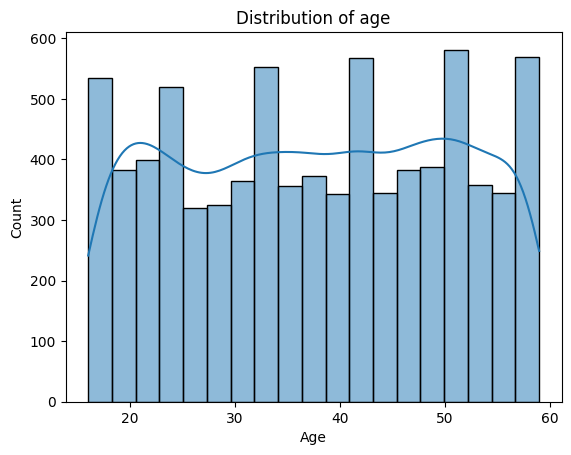

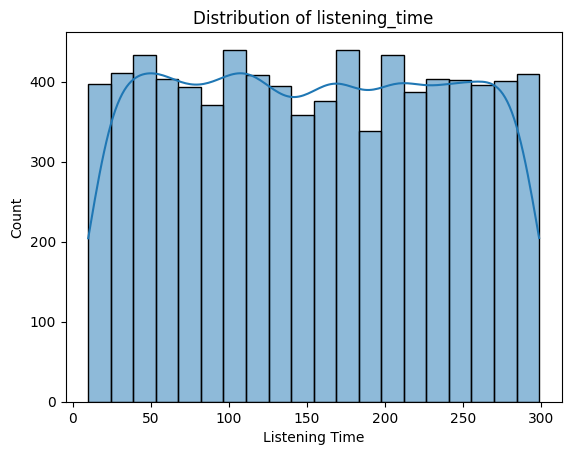

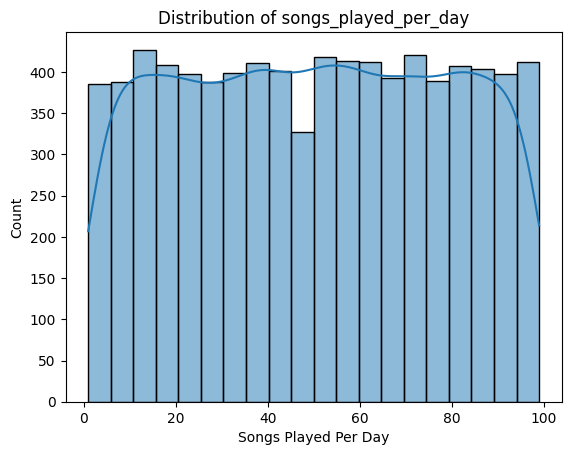

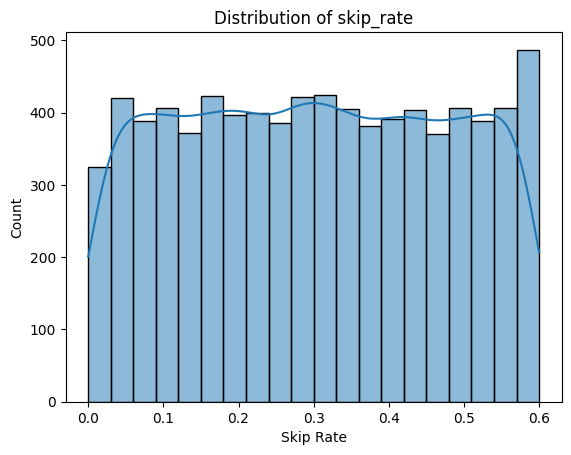

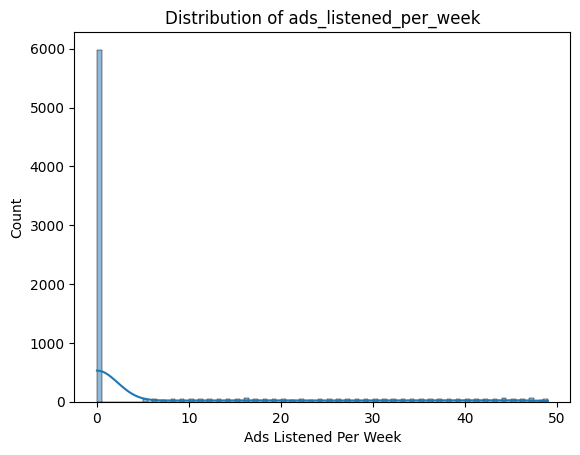

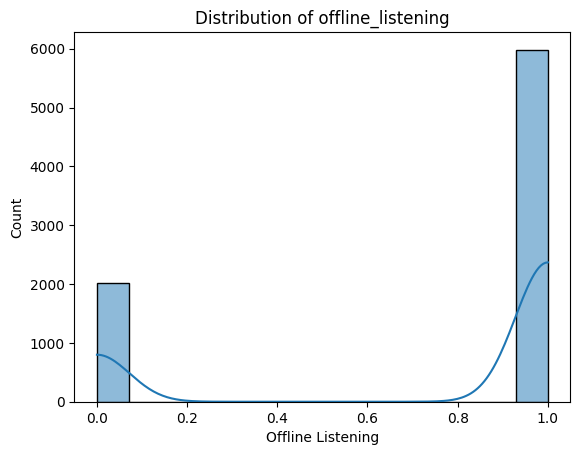

In [86]:
for col in numer_col:
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col.replace('_',' ').title())
    plt.show()

The following histograms display the distribution of numerical variables in the dataset. Overall, The numeric variables in this dataset are generally well-distributed, showing a mix of usage behaviors and demographics.

### 3.1.3 Outlier Analysis

- Identify outliers using Boxplot + IQR method
- Comment on variables with significant extreme values

In [87]:
numer_col= df.select_dtypes(include='number').drop(['user_id','is_churned'],axis =1).columns.tolist()

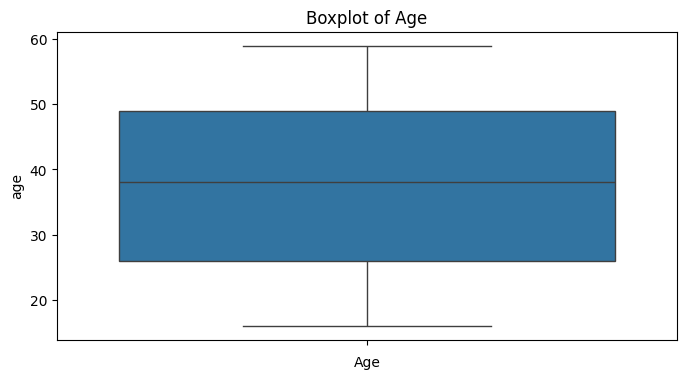

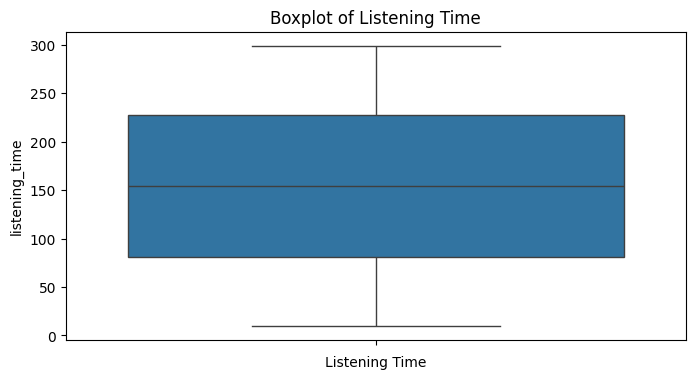

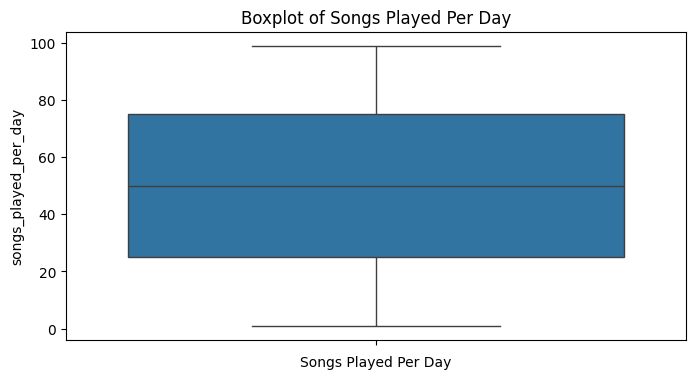

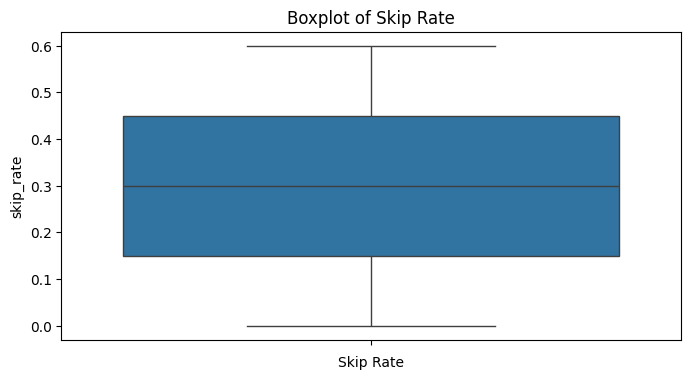

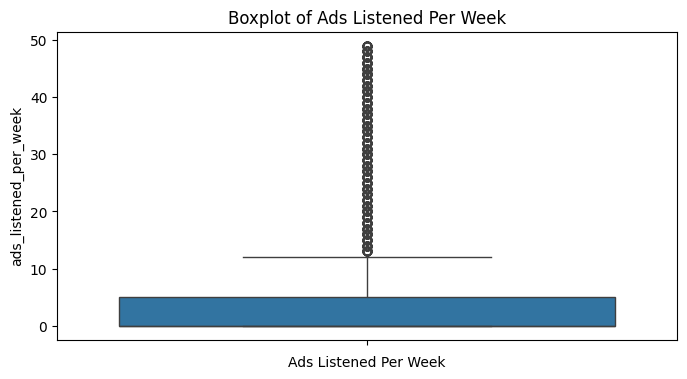

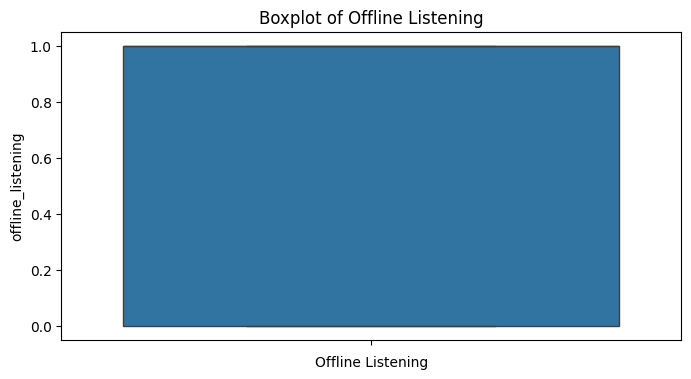

In [88]:
# Boxplot for outlier detection
for col in numer_col:
    fig,ax = plt.subplots(figsize=(8,4))
    sns.boxplot(data = df[col], ax=ax)
    plt.title(f'Boxplot of {col.replace("_"," ").title()}')
    plt.xlabel(col.replace('_',' ').title())
    plt.show()

In [89]:
# IQR Method to identify outliers 
iqr = df[numer_col].quantile(0.75) - df[numer_col].quantile(0.25)
lower_bound = df[numer_col].quantile(0.25) - (iqr * 1.5)
upper_bound = df[numer_col].quantile(0.75) + (iqr * 1.5)
outliers = ((df[numer_col] < lower_bound) | (df[numer_col] > upper_bound)).sum()
print("Number of outliers in each numerical column:\n", outliers)

Number of outliers in each numerical column:
 age                         0
listening_time              0
songs_played_per_day        0
skip_rate                   0
ads_listened_per_week    1683
offline_listening           0
dtype: int64


Only ads_listened_per_week shows a notable number of outliers,which likely represent free tier users exposed to more ads. As these reflect real usage behavior rather than anomalies, they are retained for modeling.

## 3.2 Categorical Feature Analysis
- Countplots for `gender`, `subscription_type`, `device_type`, `country`
- Discuss dominant categories and class balance


In [90]:
cat_col = df.select_dtypes(include='object').columns.tolist()
cat_col

['gender', 'country', 'subscription_type', 'device_type']

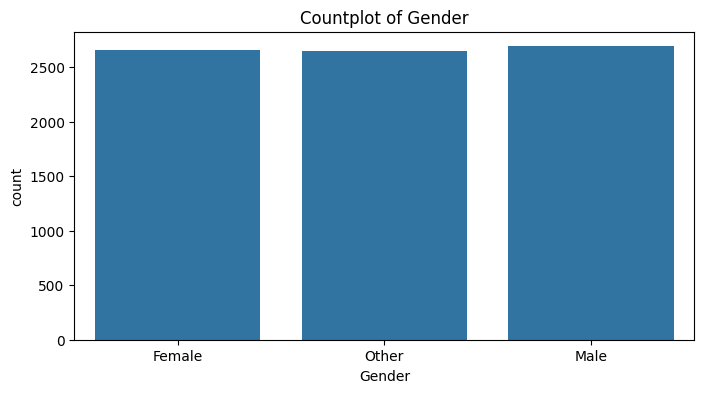

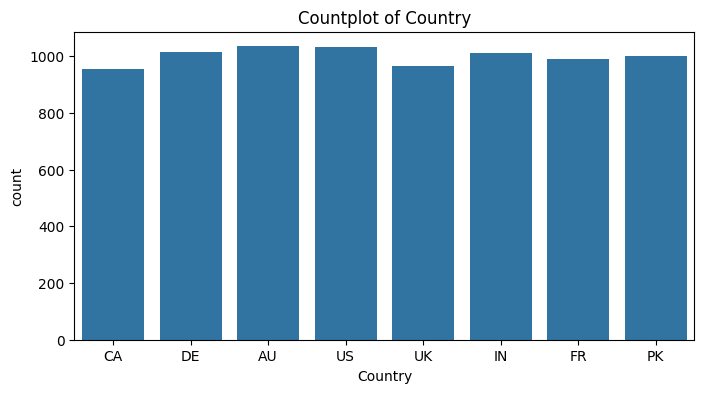

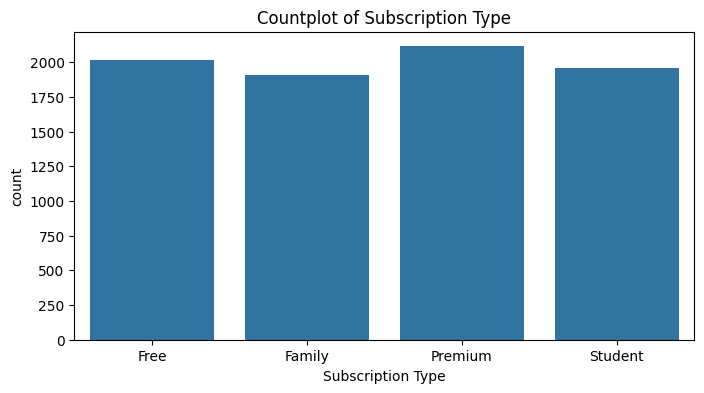

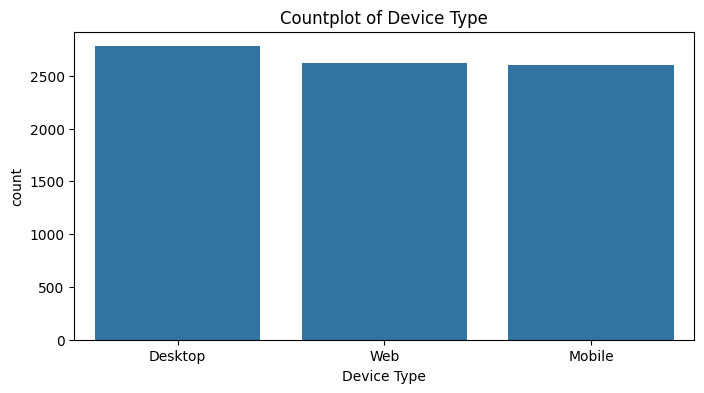

In [91]:
for col in cat_col:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col)
    plt.title(f'Countplot of {col.replace("_"," ").title()}')
    plt.xlabel(col.replace('_',' ').title())
    plt.show()

The countplots above show the frequency distribution of the categorical variables in the data set. 
- Gender: The data set depicts a balanced gender representation, with nearly equal count for male, female and other.
- Country: Users are spread across multiple countries. The count are approximately similar across all regions.
- Subscription Type: The most common subscription is premium,followed by free,student and family. This indicates that a majority of users are paid subscribers.
- Device Type: Users primarily listen though desktop,followed by web and mobile.

Overall, ther is no severe imbalance in any category,meaning all groups contribute meaningfully to the data set. However, subscription type mayy emerge as key predictor of churn.

## 3.3 Bivariate Analysis

### 3.2.1 Numerical Features vs Target (is_churned)
- Count plot / bar plots comparing numeric variables across churn groups
- Correlation analysis (Pearson correlation with churn)

<u><b>Count Plot<b><u>

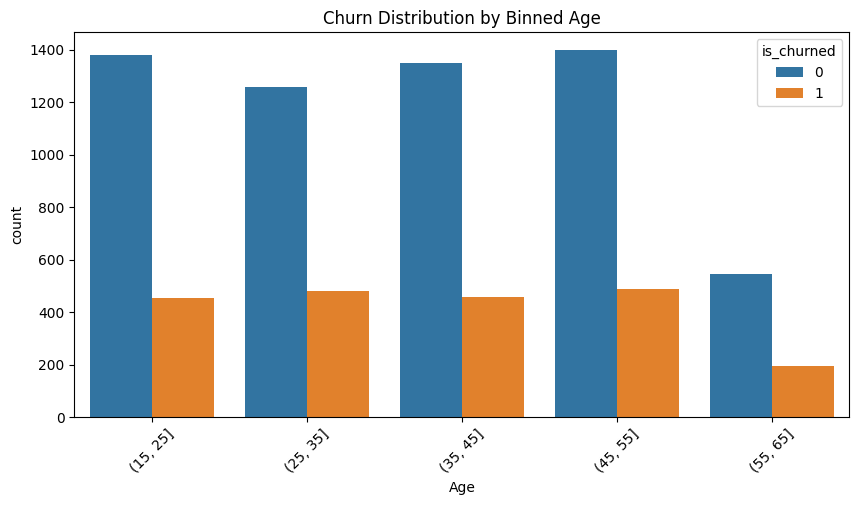

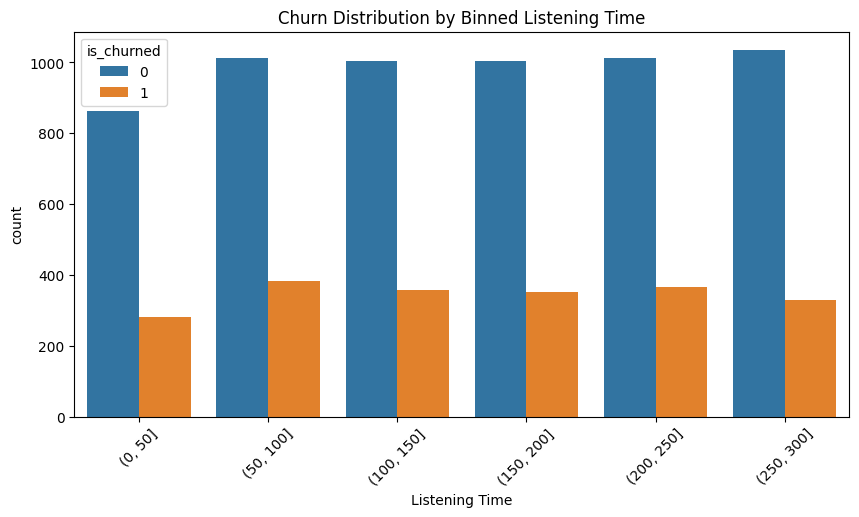

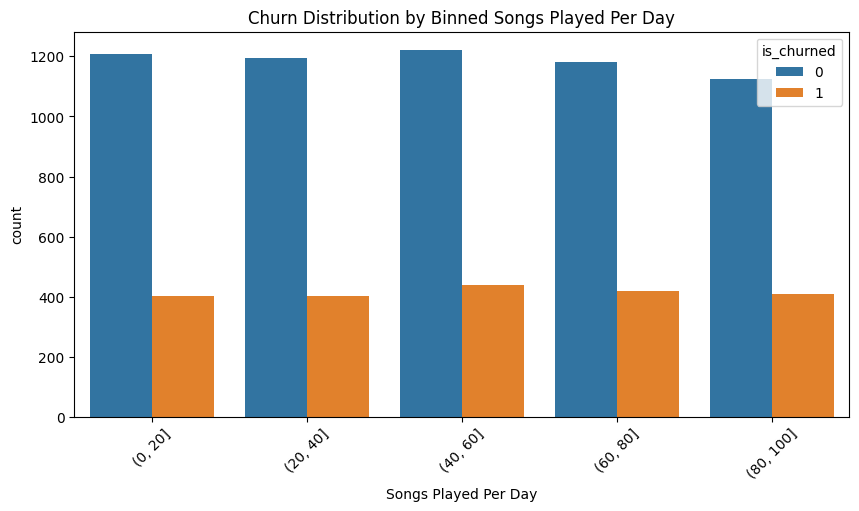

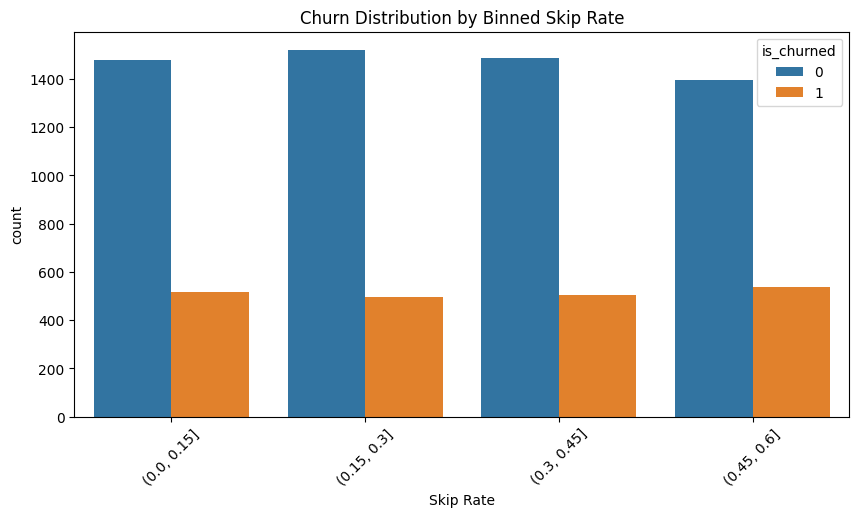

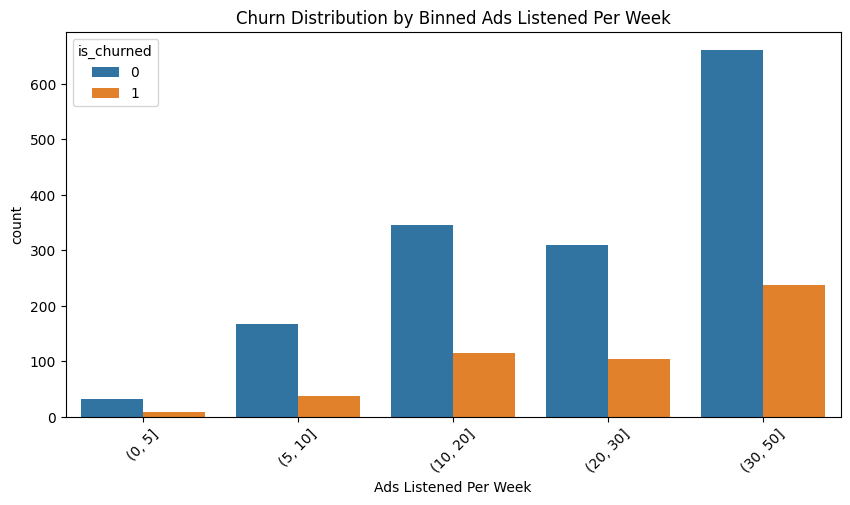

In [92]:
bin_settings = {
    'age': [15, 25, 35, 45, 55, 65],
    'listening_time': [0, 50, 100, 150, 200, 250, 300],
    'songs_played_per_day': [0, 20, 40, 60, 80, 100],
    'skip_rate': [0.0, 0.15, 0.30, 0.45, 0.60],
    'ads_listened_per_week': [0, 5, 10, 20, 30, 50],
}

for col,bins in bin_settings.items():
    df[f'{col}_binned'] = pd.cut(df[col], bins=bins)
    plt.figure(figsize=(10,5))
    sns.countplot(data=df, x=f'{col}_binned', hue='is_churned')
    plt.title(f'Churn Distribution by Binned {col.replace("_"," ").title()}')
    plt.xlabel(col.replace('_',' ').title())
    plt.xticks(rotation=45)
    plt.show()

#### Interpretation of churn distribution by numeric varaibles

1. Age: The churn distribution across age groups is fairly stable, with minor of variation. Users in all age bracket show similar churn proportion except for the oldest gropus. Overall, age does not appear to be a strong predicor of churn.

2. Listening Time: As listening time increases, the proportionof churned users decreases slightly. This suggest that higher engagement is associated with lower churn.

3. Song Played per Day:  Users who play more songs per day tend to have slighly lower churn. This pattern reinforces the idea of engagement metrics.

4. Skip rates: There is no clear pattern in the skip rate. One possible reason is that skipping behavior may reflect temporary dissatisfaction with specific songs or playlists rather than overall disengagement with the platform.

5. Ads listened per week: The plot depicts that the number of users increase with ad exposure and churned users are more numerous in groups with higher ad counts.However, since this visualization represents counts, not rates, it cannot conclusively show that higher ad frequency causes higher churn probability.

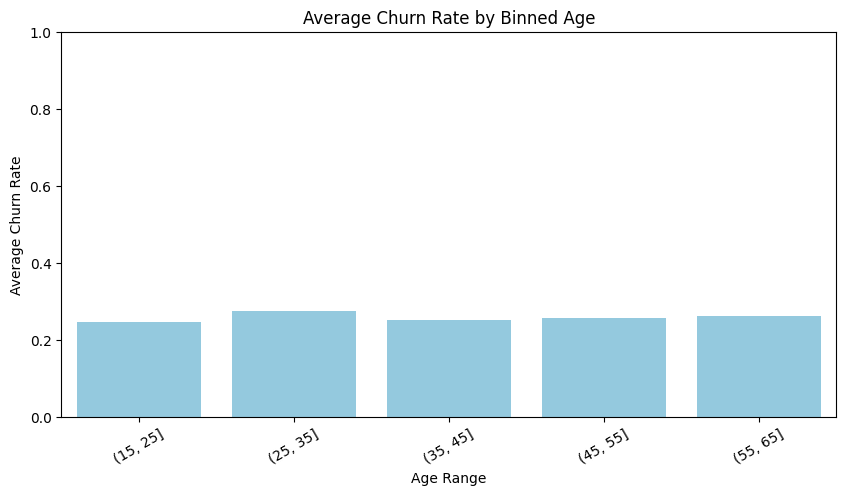

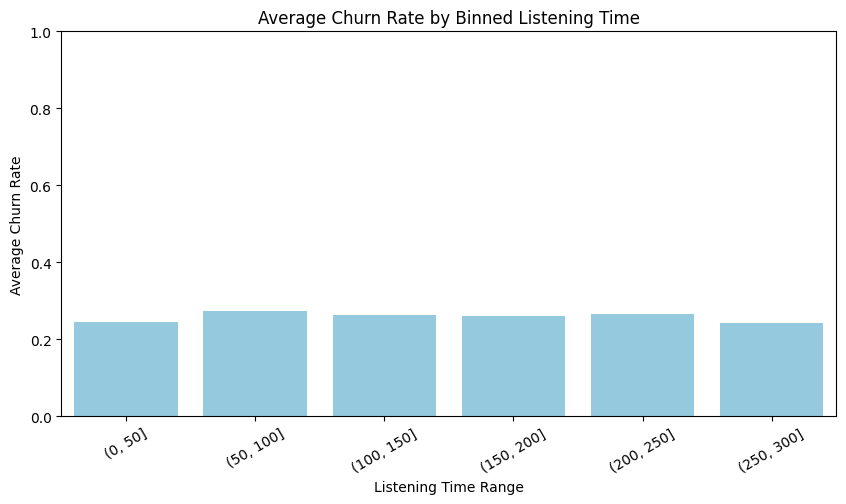

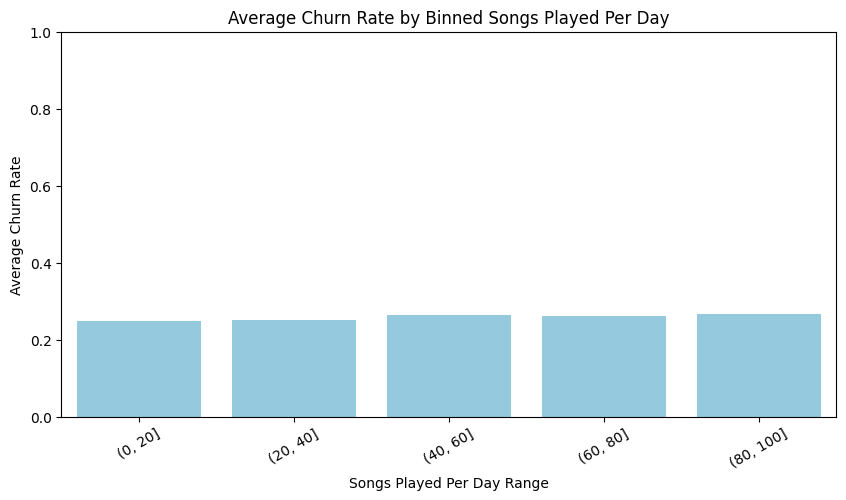

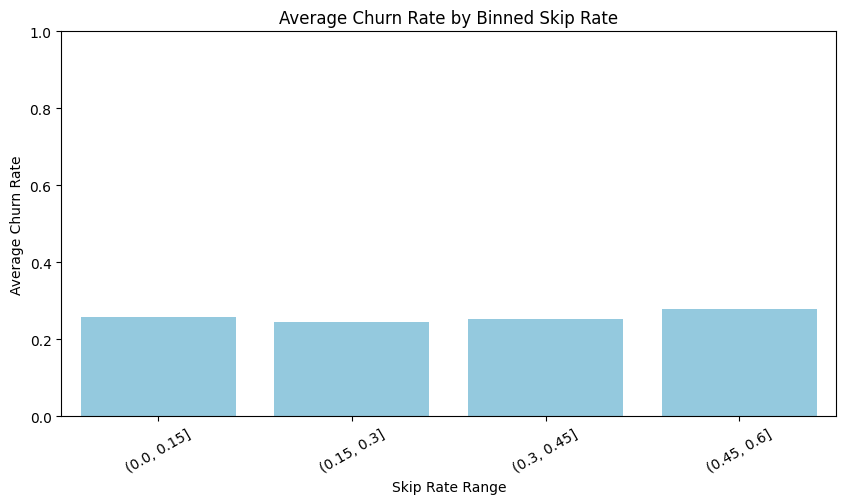

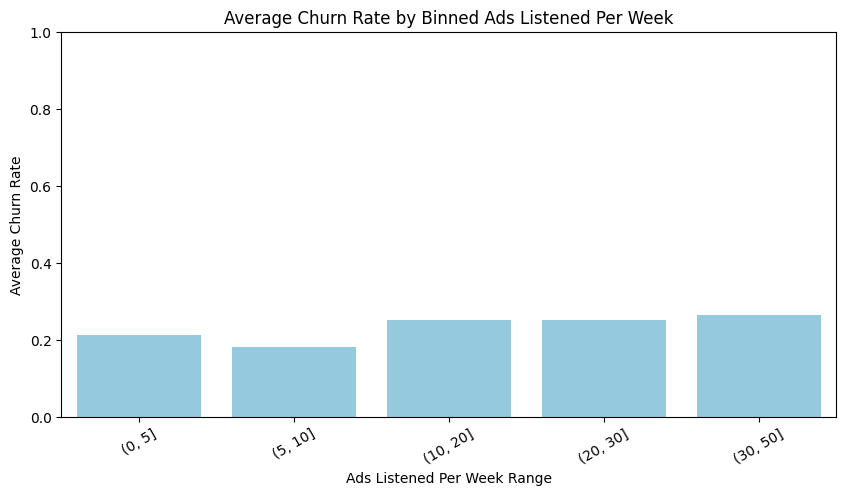

In [93]:
# Bar plot analysis

# bin settings for numerical features
bin_settings = {
    'age': [15, 25, 35, 45, 55, 65],
    'listening_time': [0, 50, 100, 150, 200, 250, 300],
    'songs_played_per_day': [0, 20, 40, 60, 80, 100],
    'skip_rate': [0.0, 0.15, 0.30, 0.45, 0.60],
    'ads_listened_per_week': [0, 5, 10, 20, 30, 50],
}

for col,bins in bin_settings.items():
    df[f'{col}_binned'] = pd.cut(df[col], bins=bins)

for col in bin_settings.keys():
    churn_rate = df.groupby(f'{col}_binned')['is_churned'].mean().reset_index()
    
    plt.figure(figsize=(10,5))
    sns.barplot(data=churn_rate, x=f'{col}_binned', y='is_churned', color='skyblue')
    
    plt.title(f'Average Churn Rate by Binned {col.replace("_", " ").title()}')
    plt.xlabel(f'{col.replace("_", " ").title()} Range')
    plt.ylabel('Average Churn Rate')
    plt.xticks(rotation=30)
    plt.ylim(0, 1)
    plt.show()

The churn rate remain relatively stable across all the groups. This suggests that no numerical variables alone is a clear driver of user churn.

<u><b>Correlation<b><u>



In [94]:
corr = df.corr(numeric_only= True).drop('user_id', axis=1)
corr['is_churned'].sort_values(ascending=False)[1:]

skip_rate                0.016121
offline_listening        0.012754
songs_played_per_day     0.009314
age                      0.003982
ads_listened_per_week   -0.002279
listening_time          -0.007624
user_id                 -0.015994
Name: is_churned, dtype: float64

Text(0.5, 1.0, 'Correlation Matrix')

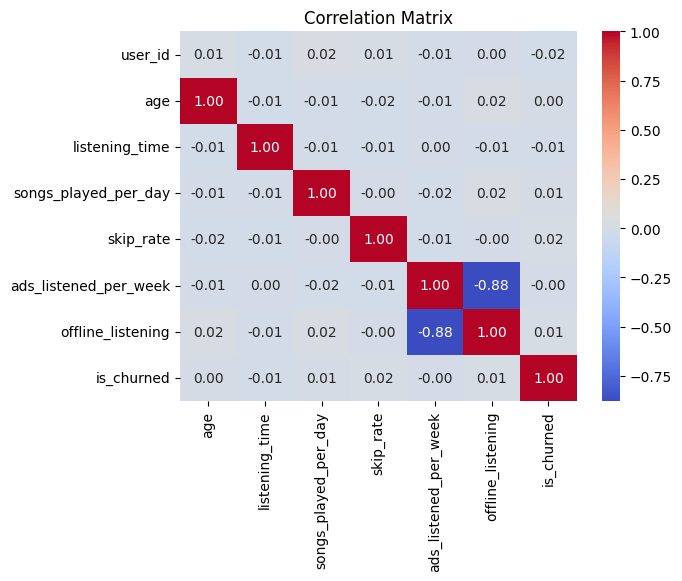

In [95]:
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')

The correlation between numerical variables and the target variable(`is_churned`) are very close to zero. Thus, This implies that user churn is not linearly related to any single behavior variable but may depend on combinations of features and categorical effects such as subscription type or device usage.

### 3.2.2 Categorical Features vs Target

- Grouped countplots
- Compare churn rates across categories (e.g., subscription_type, gender)


<u><b>Countplots<b><u>

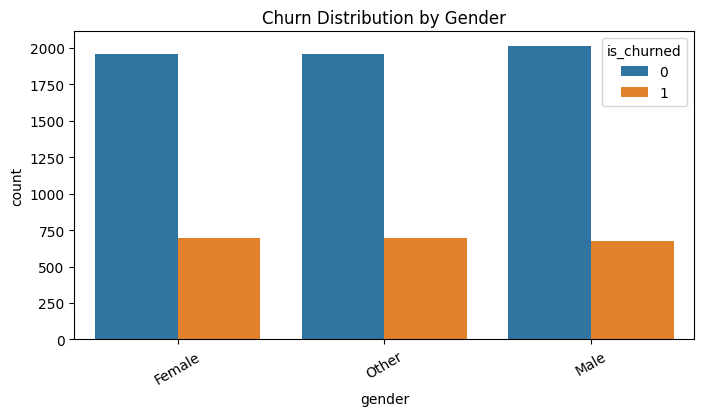

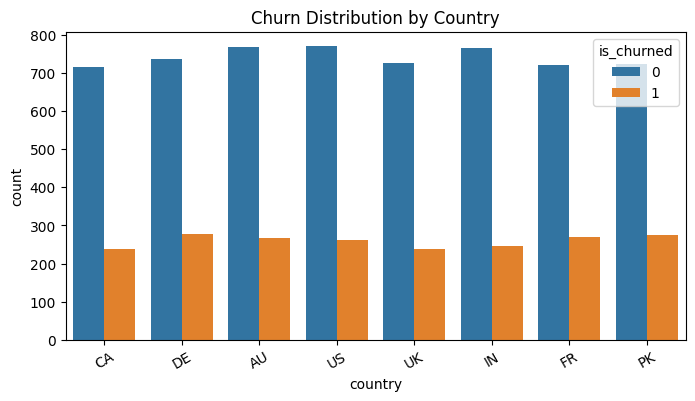

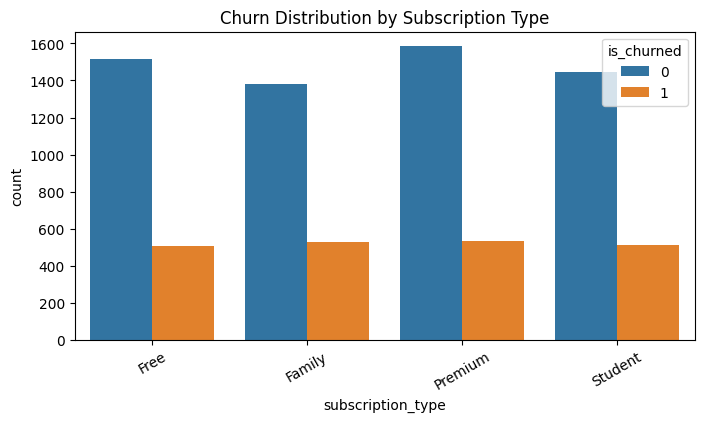

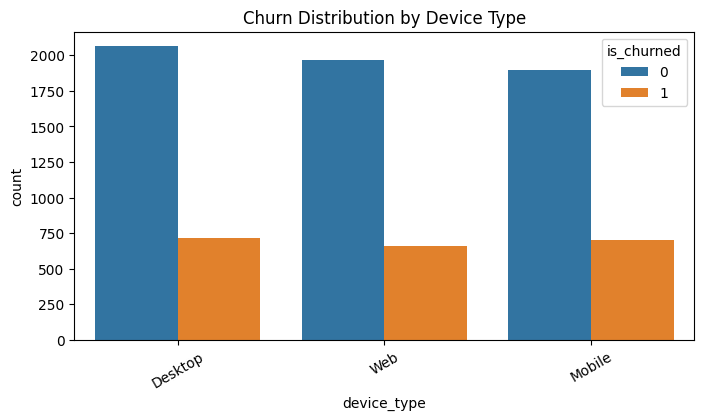

In [96]:
for col in cat_col:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, hue='is_churned')
    plt.title(f'Churn Distribution by {col.replace("_"," ").title()}')
    plt.xticks(rotation=30)
    plt.show()

The churn distribution across of alll categories is farily uniform. This indicates that there are no strong categorical differences in churn behavior.

<u><b>Barplots of churn rates<b><u>

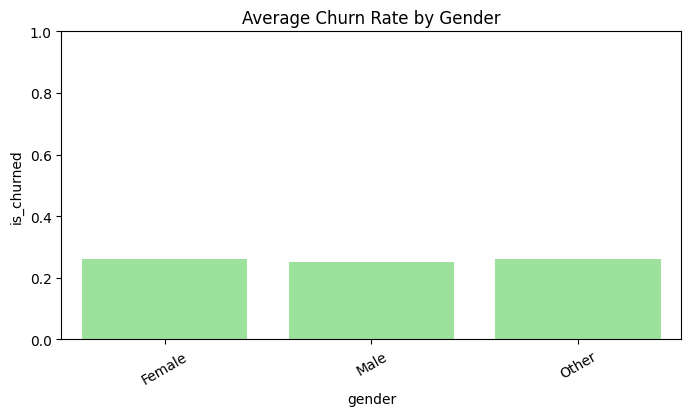

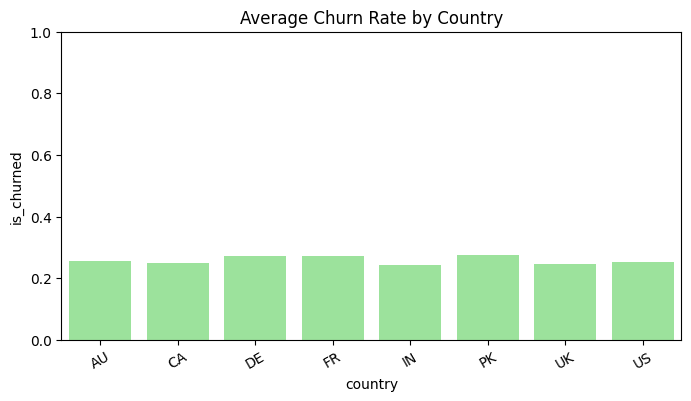

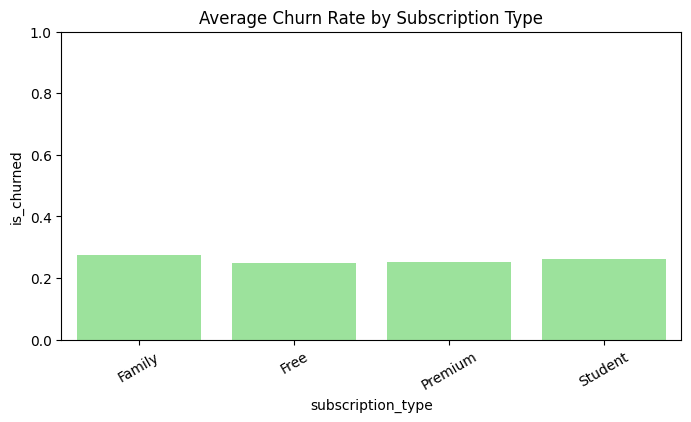

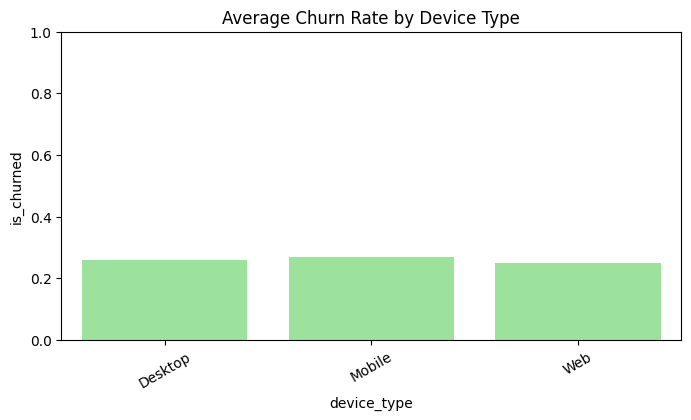

In [97]:
for col in cat_col:
    churn_rate = df.groupby(col)['is_churned'].mean().reset_index()
    plt.figure(figsize=(8,4))
    sns.barplot(data=churn_rate, x=col, y='is_churned', color='lightgreen')
    plt.title(f'Average Churn Rate by {col.replace("_"," ").title()}')
    plt.xticks(rotation=30)
    plt.ylim(0, 1)
    plt.show()

The churn rates across all grops is nearly identical for all categorical features. These finding suggests that categoriacal fators alone are weak predictor for user's churn.

## 4.1 Modeling 

### Model preparation

The independent variables and dependent variable are defined according to the model objective. All categorical variables are transformed into a dummy variables to ensure compatiblity with machine learning algorithms. The data is splited into training and test sets using an 80:20 ratio to evaluate the model's performance.

In [98]:
# Create dummy variables for categorical features
df = df.drop(['age_binned', 'listening_time_binned', 'songs_played_per_day_binned',
       'skip_rate_binned', 'ads_listened_per_week_binned'], axis=1)

In [99]:
# Create dummy variables for categorical features
df_encoded = pd.get_dummies(df, columns=cat_col, drop_first=True,dtype=int)

# Define independent and dependent variables
X = df_encoded.drop(['user_id','is_churned'], axis=1)
y = df_encoded['is_churned']

# Split the data into training and testing sets]
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [100]:
# Apply SMOTE to balance the classes in the training set
smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)

From the data observation, the churn =1 accounts for 25 percent of the data. Thus, class weight balanced is applied in the logistic model.

In the next section, several machine learning classification models are applied to predict user's churn. The objective is to evaluate how well each model can classify obsevations based on given features.

<u><b>Model Evaluation Function</b></u>

In [101]:
def eval_model(model, x_train, y_train, x_test, y_test,param_grid,prob_threshold=0.2):

    model_name = type(model).__name__
    prefix = model_name.lower().replace('classifier', '').replace('regression', '')[:5]

    ### Baseline model
    # Fit the model
    model.fit(x_train, y_train)
    pred = model.predict(x_test)
    prob = model.predict_proba(x_test)[:,1]  # Probability of churn class
    pred_adj = (prob >= prob_threshold).astype(int) # set prob > 0.2 as churn
    # Feature importance for baseline model
    if hasattr(model, 'feature_importances_'):
        baseline_feature_importances = pd.Series(model.feature_importances_,
                                                  index=x_train.columns).sort_values(ascending=False)
    else:
        baseline_feature_importances = None


    # Default model(eval scores)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, pred)
    
    # Adjusted model for baseline(eval scores)
    accuracy_adj = accuracy_score(y_test, pred_adj)
    precision_adj = precision_score(y_test, pred_adj)
    recall_adj = recall_score(y_test, pred_adj)
    f1_adj = f1_score(y_test, pred_adj)
    roc_auc_adj = roc_auc_score(y_test, pred_adj)


    ### Grid CV model
    grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring='f1', cv=3, n_jobs=-1, verbose=2)
    grid.fit(x_train, y_train)
    best_model = grid.best_estimator_ # grid best model
    grid_pred = best_model.predict(x_test)
    grid_prob = best_model.predict_proba(x_test)[:,1]
    grid_pred_adj = (grid_prob >= prob_threshold).astype(int)

    # best parameters
    best_params = grid.best_params_

    # Feature importance for the grid model
    if hasattr(best_model, 'feature_importances_'):
        grid_feature_importances = pd.Series(best_model.feature_importances_, 
                                             index=x_train.columns).sort_values(ascending=False)
    else:
        grid_feature_importances = None
        
    # Grid CV model default(eval scores)
    accuracy_grid = accuracy_score(y_test, grid_pred)
    precision_grid = precision_score(y_test, grid_pred)
    recall_grid = recall_score(y_test, grid_pred)
    f1_grid = f1_score(y_test, grid_pred)
    roc_auc_grid = roc_auc_score(y_test, grid_pred)

    # Grid CV model adjusted(eval scores)
    accuracy_grid_adj = accuracy_score(y_test, grid_pred_adj)
    precision_grid_adj = precision_score(y_test, grid_pred_adj)
    recall_grid_adj = recall_score(y_test, grid_pred_adj)
    f1_grid_adj = f1_score(y_test, grid_pred_adj)
    roc_auc_grid_adj = roc_auc_score(y_test, grid_pred_adj)

    ### Summary table
    rev_table = pd.DataFrame({
        'Model': [type(model).__name__, 
                  f'{type(model).__name__} (Adjusted Threshold {prob_threshold})',
                  f'{type(model).__name__} GridSearchCV',
                  f'{type(model).__name__} GridSearchCV (Adjusted Threshold {prob_threshold})'],
        'Accuracy': [accuracy,accuracy_adj,accuracy_grid,accuracy_grid_adj],
        'Precision': [precision,precision_adj,precision_grid,precision_grid_adj],
        'Recall': [recall,recall_adj,recall_grid,recall_grid_adj],
        'F1 Score': [f1,f1_adj,f1_grid,f1_grid_adj],
        'ROC AUC': [roc_auc,roc_auc_adj,roc_auc_grid,roc_auc_grid_adj]
    })

    rev_table = rev_table.set_index('Model').T

    globals()[f"{model_name}_result_table"] = rev_table.T
    globals()[f"{prefix}_best_model"] = best_model  
    

    print(f"{model_name} completed. Table saved as '{model_name}_result_table' and model as '{prefix}_best_model'")
    print('\n')
    print("Best Parameters from Grid Search:", best_params)

    # plot features importances when the model is not logistic regression
    if not isinstance(model, LogisticRegression):
        if baseline_feature_importances is not None:
            print("\nBaseline Model Feature Importances:\n")
            plt.figure(figsize=(10,6))
            sns.barplot(x=baseline_feature_importances, 
                        y=baseline_feature_importances.index.str.replace('_', ' '), palette='viridis')
            plt.title(f'Feature Importances from {model_name}')
            plt.xlabel('Importance Score')
            plt.ylabel('Features')
            plt.show()
    
        if grid_feature_importances is not None:
            print("\nGrid Search Best Model Feature Importances:\n")
            plt.figure(figsize=(10,6))
            sns.barplot(x=grid_feature_importances, 
                        y=grid_feature_importances.index.str.replace('_', ' '), palette='viridis')
            plt.title(f'Feature Importances from Best {model_name} after Grid Search')
            plt.xlabel('Importance Score')
            plt.ylabel('Features')
            plt.show()

    return rev_table.T,best_model

The `eval_model()` function automates the evaluation and comparison of machine learning classification models.
It performs three key steps:

1. <b>Baseline Evaluation</b> - Fits the initial model on the training data and evaluates it on the test set using key matrics(Accuracy, Precision, Recall, F1, ROC-AUC)

2. <b>Threshold Adjusstment</b> - Recaluculates predictions using a custom probability threshold of 0.2 to handle class imabalanced and recall score in order to capture more churn targets

3. <b>Hyperparameter Optimization</b> - Tunes the model parameter to improve performance based on the cross validated F1 score. 

This function will return a summary table with model's performance acorss therse configurations, resulting in easier model commparision.

---

### Feature Importance Visualization

- For c, the function automatically plots the **top 10 most important features** for both:
  - The **baseline model**, and  
  - The **tuned model after GridSearchCV**.

- For `Logistic Regression`, plots are **skipped automatically**,  as its coefficients represent **directional effects** rather than feature importance scores.

---

### Outputs

The function returns one elements:

1. `rev_table.T` - a summary table comparring metrics across all configurations



## 4.1.1 Logistic Regresstion

Logistic Regression is used as the baseline model to predict the user's churn.It estiamtes the probability of an obsevation belonging to particual classed based on the independent variable. Grid Search CV is also be applied in this part to tune hyperparameters and find the best parameters.

In [102]:
# Create model and parameter grid for Logistic Regression
model = LogisticRegression(class_weight='balanced',random_state=42)
param_grid = {
    'C':[0.01,0.1,1,10,100],
    'penalty':['l1','l2'],
    'solver':['liblinear'],
    'class_weight':['balanced',None]}

# Evaluate Logistic Regression model
logit_table,_ =eval_model(model,   # logit base 
           x_train=x_train,
           y_train=y_train,
           x_test=x_test,
           y_test=y_test,
           param_grid=param_grid,
           prob_threshold=0.2)
print(logit_table)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
LogisticRegression completed. Table saved as 'LogisticRegression_result_table' and model as 'logis_best_model'


Best Parameters from Grid Search: {'C': 100, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
                                                    Accuracy  Precision  \
Model                                                                     
LogisticRegression                                  0.652500   0.251592   
LogisticRegression (Adjusted Threshold 0.2)         0.354375   0.244964   
LogisticRegression GridSearchCV                     0.665625   0.250923   
LogisticRegression GridSearchCV (Adjusted Thres...  0.360625   0.244463   

                                                    Recall  F1 Score   ROC AUC  
Model                                                                           
LogisticRegression                                  0.1975  0.221289  0.500833  
LogisticRegression 

The base line `Logistic Regression` model achieves an accuracy of of 65%, with low precision (25%) and recall (20%). This result shows that the model struggles to conrrectly identify churn cases. After lowering the probability threshold to 0.2, it improves recall score signigficantly to 76%, meaning that the model captures more true churns. However, the accuracy drop to 35 %.

This shows a clear trade-off between precision and recall. Imporving recall score come with a costt of more false positive.

Grid Search CV tuning produced similar overll performance,indicating that hyuperparameter optimization provides slightly improvement for this model.

Overall, `Logistic Regression`has limited predictive power for this data and alternative models may perform better.

## 4.1.2 Decision Tree

To further enhance performance, a Decision tree classifier is introduced. Decision tree can captuer non-linear patterns and complex interactions among feature. 

Fitting 3 folds for each of 120 candidates, totalling 360 fits
DecisionTreeClassifier completed. Table saved as 'DecisionTreeClassifier_result_table' and model as 'decis_best_model'


Best Parameters from Grid Search: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 10, 'max_features': 'sqrt', 'random_state': 42, 'splitter': 'random'}

Baseline Model Feature Importances:



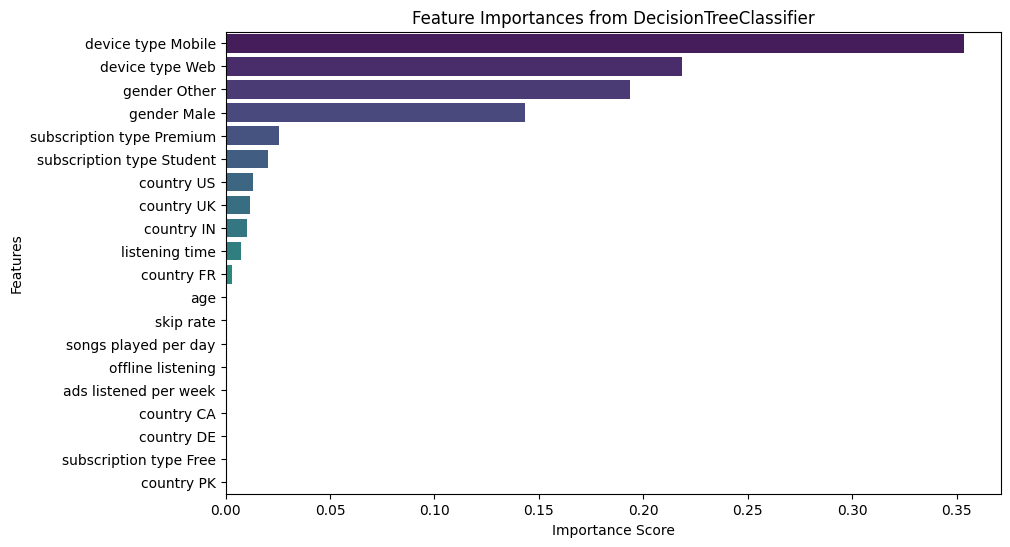


Grid Search Best Model Feature Importances:



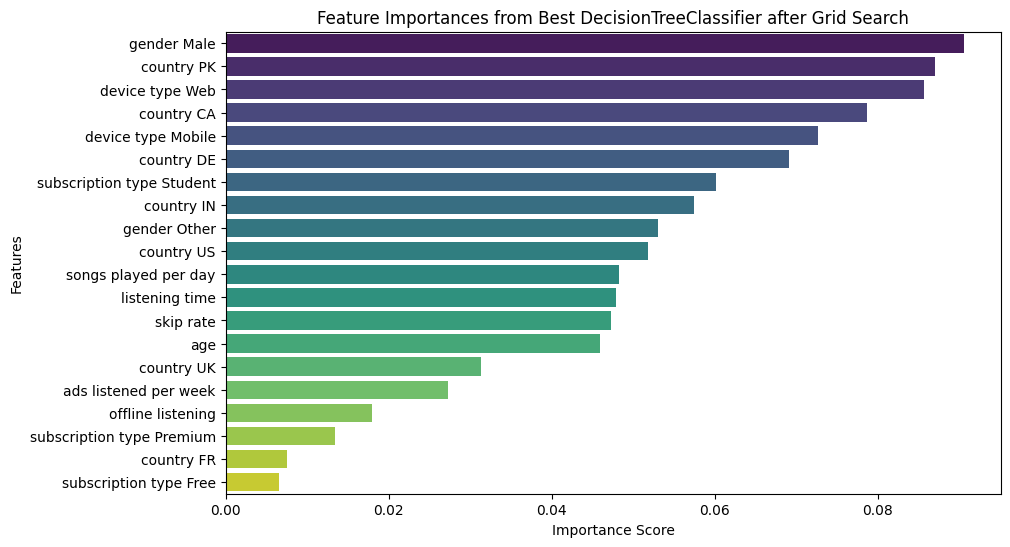


 Decision Tree Classifier Results:
                                                    Accuracy  Precision  \
Model                                                                     
DecisionTreeClassifier                              0.631250   0.228571   
DecisionTreeClassifier (Adjusted Threshold 0.2)     0.270625   0.249510   
DecisionTreeClassifier GridSearchCV                 0.602500   0.223005   
DecisionTreeClassifier GridSearchCV (Adjusted T...  0.358125   0.251781   

                                                    Recall  F1 Score   ROC AUC  
Model                                                                           
DecisionTreeClassifier                              0.2000  0.213333  0.487500  
DecisionTreeClassifier (Adjusted Threshold 0.2)     0.9550  0.395650  0.498750  
DecisionTreeClassifier GridSearchCV                 0.2375  0.230024  0.480833  
DecisionTreeClassifier GridSearchCV (Adjusted T...  0.7950  0.382441  0.503750  


In [103]:
# Create model and tuning paramters for Decision Tree Classifier
model = DecisionTreeClassifier(max_depth=4,class_weight='balanced',random_state=42)
param_grid = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [3, 4, 5, 10, 15],
    'max_features': [None, 'sqrt', 'log2'],
    'class_weight': ['balanced', None],
    'random_state': [42]    
}

# Evaluate Decision Tree Classifier
dt_table,dt_bestmodel =eval_model(model,
           x_train=x_train,
           y_train=y_train,
           x_test=x_test,
           y_test=y_test,
           param_grid=param_grid,
           prob_threshold=0.2)
print("\n Decision Tree Classifier Results:")
print(dt_table)

### Feature Importance Visualization - Decision Tree Classifier

The following plots depicts how feature importance changes **before and after the hyperparameters tunning** using Grid Search CV.

---
### Baseline model

- The **first plot** represents the **baseline mode** shows that device type is the major factors that influence in predicting churn. Gendor also contribures moderately,followed by subscription type and country.
- These variables account for most of the model’s decision-making power, while other features contribute minimally.
- This indicates that the baseline model may be **overfitting** , as it focuses narrowly on certain attributes without learning broader patterns in user behavior.

--- 

### Tuned model
- The **second plot** shows that feature importances become more evenly distributed across multiple varaibles. This suggest that the optimized model captures broader relationships and provides better generalization.

---




### Model Evaluation: Decision Tree Classifier

The summary table summarizes the Decision Treemodel's performance uner four configurations:

**1. Baseline Model (Default Threshold)**
- **Accuracy:** 0.63  
- **Precision:** 0.23  
- **Recall:** 0.20  
- **F1 Score:** 0.21  
- **ROC-AUC** 0.49 \
The baseline Decision Tree shows moderate accuracy but low recall. This result indicates that  it misses many churn cases. Precision is also low, suggesting a fair number of false positives.

---

**2. Adjusted Threshold (0.2)**
- **Accuracy:** 0.27  
- **Precision:** 0.25  
- **Recall:** 0.96  
- **F1 Score:** 0.4
- **ROC-AUC**  0.5\
After lowering the threshold, the model becomes highly sensitive, capturing nearly all churn cases  but at the cost of very low accuracy and precision. 

---

**3. GridSearchCV Tuned Model**
- **Accuracy:** 0.60  
- **Precision:** 0.22  
- **Recall:** 0.24  
- **F1 Score:** 0.23
- **ROC-AUC**  \
Hyperparameter tuning slightly improved recall but not significantly. The model still struggles to generalize well and does not outperform the baseline by much.

---

**4. Tuned Model with Adjusted Threshold (0.2)**
- **Accuracy:** 0.36  
- **Precision:** 0.25  
- **Recall:** 0.80  
- **F1 Score:** 0.38 
- **ROC-AUC** 0.5 \
After applying threshold adjustment to the tuned model, recall improves substantially, with a more balanced trade-off between precision and recall.
---

### SHAP Analysis

<u><b>SHAP Additivity Verification<b><u>

In [104]:
# Initialize SHAP tree explainer
explainer = shap.TreeExplainer(dt_bestmodel)

# calculate SHAP values for test set
print('Calculating SHAP values')
shap_values = explainer.shap_values(x_test)
shap_values_class1 = shap_values[...,1]
print(f"SHAP values calculated for {shap_values_class1.shape[0]} predictions")
print(f"Each predictions are explained by {shap_values_class1.shape[1]} features")

print(f"The model's expected value for:${explainer.expected_value[1]:.2f}")
# selcect shap values for class 1 (churned)

# Quick Verification of additivity property for SHAP values
i = 0
class_id = 1
model_pred = dt_bestmodel.predict_proba(x_test.iloc[[i]])[0,class_id]
shap_sum = explainer.expected_value[1] + shap_values_class1[i].sum()
print(f"Model prediction: ${model_pred:.2f}")
print(f"SHAP values sum + expected value: {shap_sum:.2f}")

Calculating SHAP values
SHAP values calculated for 1600 predictions
Each predictions are explained by 20 features
The model's expected value for:$0.50
Model prediction: $0.15
SHAP values sum + expected value: 0.15


The result confirms that the SHAP computation for the Decision Tree model is accurate and consistent with a model's predictive probability of **0.15** for the selected observation. This value is identical to **the sum of SHAP feature contributions plus the expected base value of 0.5**, verifying the additive property of SHAP model.

<u><b>Global Feature Importance<b><u>

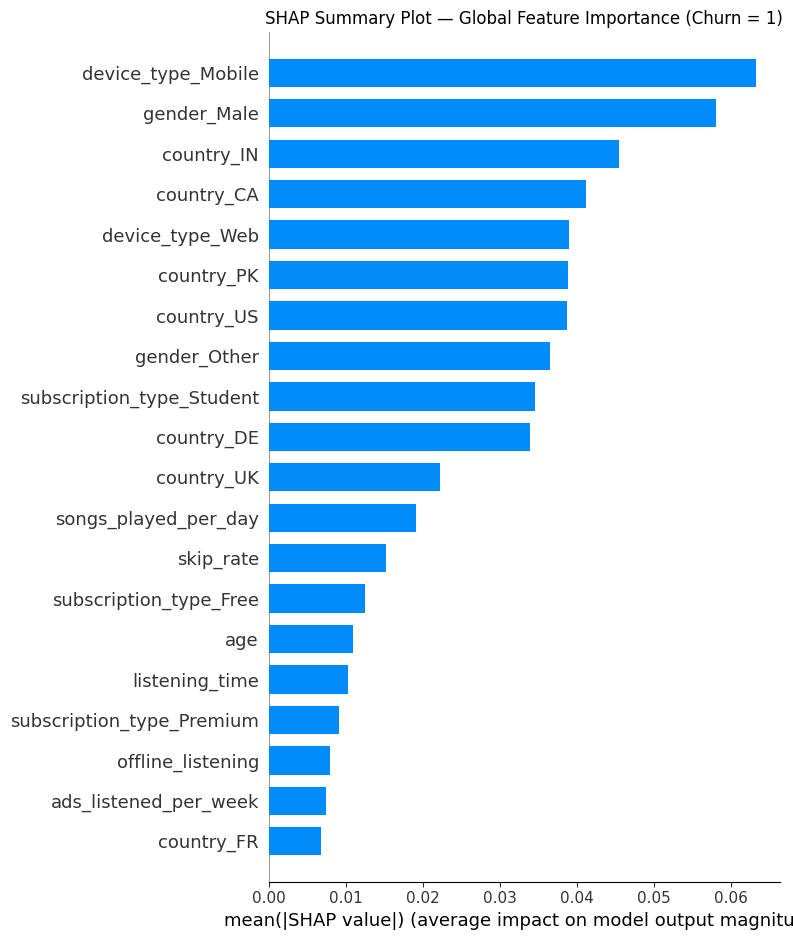

In [105]:
# --- Global Feature Importance (bar chart)
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values_class1, x_test, plot_type="bar", show=False)
plt.title("SHAP Summary Plot — Global Feature Importance (Churn = 1)")
plt.tight_layout()
plt.show()

The SHAP plot provides a global interpretaition of the model by showing which features have the greatest overall impact on predictive churn

Device type hat the highest influence on churn prediction, followed by gender and country. This suggest that churn is more strong influenced by **user type and access context** rather than behavioral engagement.

<u><b>Detailed Feature Impact<b><u>

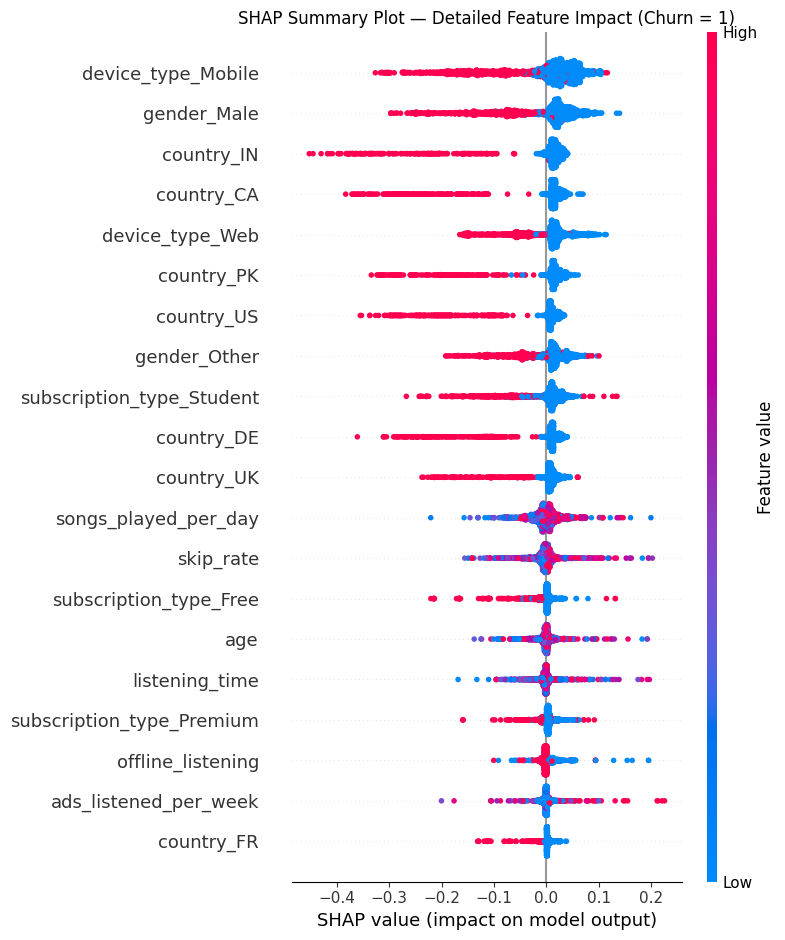

In [106]:
# --- Detailed Feature Impact
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values_class1, x_test, show=False)
plt.title("SHAP Summary Plot — Detailed Feature Impact (Churn = 1)")
plt.tight_layout()
plt.show()

The chart confirms that device type and user demographics dominate churn prediction. Behavioral features provides finer adjustments but less decisive overall.

<u><b>Individual Prediction Explanation<b><u>

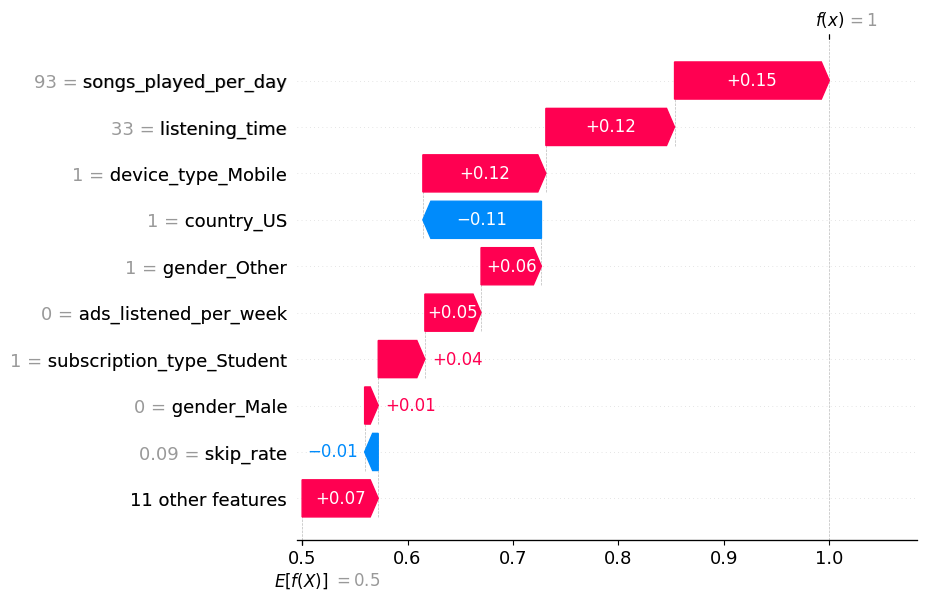

In [107]:
# Identify the index of the instance with the highest predicted churn probability
dt_pred_probs = dt_bestmodel.predict_proba(x_test)[:,1]
highest_idx = dt_pred_probs.argmax()
shap_val_highest = shap_values_class1[highest_idx]

# Plot waterfall for the highest predicted churn probability
shap.plots.waterfall(shap.Explanation(values=shap_val_highest,
                                      base_values=explainer.expected_value[1],
                                      data=x_test.iloc[highest_idx],
                                        feature_names=x_test.columns))

The SHAP waterfall plot explains the model's churn prediction for a single user, with final predicted probability of 1. The main factors driving this are a high number of songs played per day,long listening time and mobile device usage. Being in the US slightly reduces the risk. Overall, churn is driven by intensive usage on mobile and content fatigue.

## 4.1.3 Random Forest

<u><b>Global Feature Importance<b><u>

To imporve prediction ability, Random Forest is implemented to increase generaliazation performance and reduces variance. 

Fitting 3 folds for each of 288 candidates, totalling 864 fits
RandomForestClassifier completed. Table saved as 'RandomForestClassifier_result_table' and model as 'rando_best_model'


Best Parameters from Grid Search: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 15, 'max_features': 'sqrt', 'n_estimators': 200, 'random_state': 42}

Baseline Model Feature Importances:



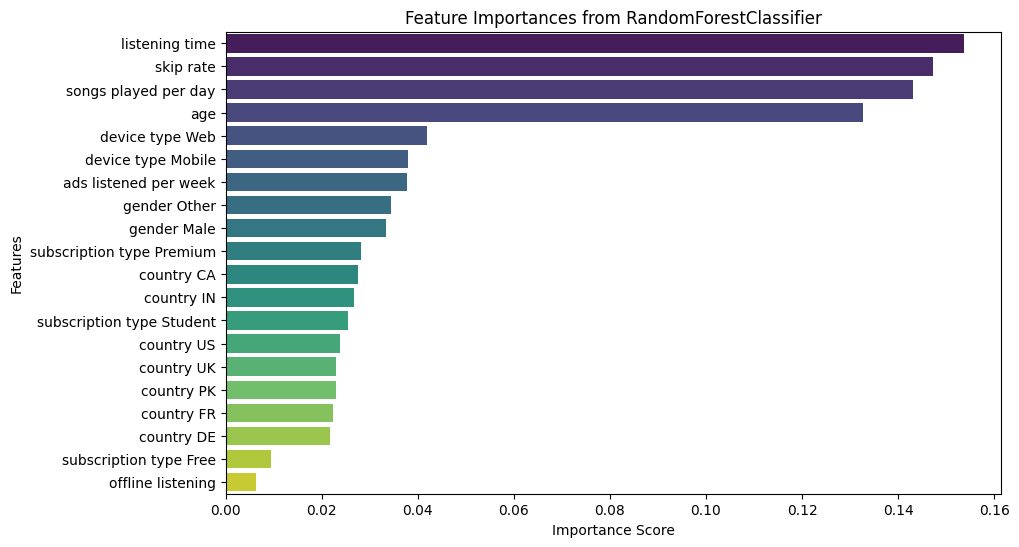


Grid Search Best Model Feature Importances:



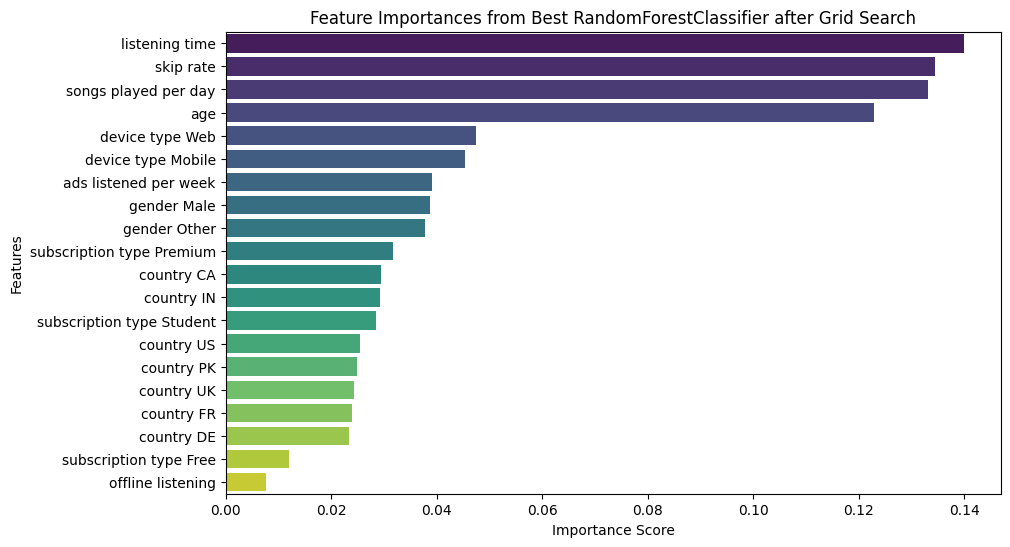


 Random Forest Classifier Results:
                                                    Accuracy  Precision  \
Model                                                                     
RandomForestClassifier                              0.695000   0.298165   
RandomForestClassifier (Adjusted Threshold 0.2)     0.350000   0.259398   
RandomForestClassifier GridSearchCV                 0.683125   0.272340   
RandomForestClassifier GridSearchCV (Adjusted T...  0.311250   0.251768   

                                                    Recall  F1 Score   ROC AUC  
Model                                                                           
RandomForestClassifier                              0.1625  0.210356  0.517500  
RandomForestClassifier (Adjusted Threshold 0.2)     0.8625  0.398844  0.520833  
RandomForestClassifier GridSearchCV                 0.1600  0.201575  0.508750  
RandomForestClassifier GridSearchCV (Adjusted T...  0.8900  0.392503  0.504167  


In [108]:
# Create and train the Random Forest model
model = RandomForestClassifier(class_weight='balanced',random_state=42)
param_grid = {
    'n_estimators':[50,100,200],
    'criterion':['gini','entropy'],
    'max_depth':[None,1,2,3,4,5,10,15],
    'max_features':['auto','sqrt','log2'],
    'class_weight':['balanced',None],
    'random_state':[42]
}

# Evaluate the Random Forest model
rf_table,rf_bestmodel = eval_model(model,
           x_train=x_train,
           y_train=y_train,
           x_test=x_test,
           y_test=y_test,
           param_grid=param_grid,
           prob_threshold=0.2)

print("\n Random Forest Classifier Results:")
print(rf_table)

### Feature Importance Visualization - Random Forest Classifier

The following plots display the **feature importance ranking* for the Random Forest model.

---

### Baseline model
- The baseline model empahsizes on behavioral features such as `listening_time`,`skip_rate`, and `song_played_per_day` followed by demographic factor like `age`

- This suggests that **user engagement metrics** are the most influetial factor for predicting churn.

- The model may not be fully optimized on how it balances feature usage.

---

### Tuned model

- After tuning , the feature importance ranking remain consistent with the baseline model.

- The impoortance scores are slightly more balances. However, it does fully optimized on balancing features usage.

---



### Model Evaluation - Random Forest Classifier

The summary table summarizes the Random Forest model's performance uner four configurations:

**1. Baseline Model**
- **Accuracy:** 0.695 
- **Precision:** 0.2982  
- **Recall:** 0.1625
- **F1 Score:** 0.2104
- **ROC-AUC** 0.5175\
The baseline **Random Frorest** achieves an accuracy of **69.5%** but the recall score is around 16%, meaning the model misses many churned uses.

---

**2. Adjusted Threshold (0.2)**
- **Accuracy:** 0.35 
- **Precision:** 0.26 
- **Recall:** 0.86
- **F1 Score:** 0.40
- **ROC-AUC** 0.52\
After lowering the threshold, recall score imporves significantly to **86%** whereas, the accuracy decrease to **35%** dut to the trade off.

---

**3. GridSearchCV Tuned Model**
- **Accuracy:** 0.6831
- **Precision:** 0.27 
- **Recall:** 0.16
- **F1 Score:** 0.20
- **ROC-AUC**  0.51
**Grid Search CV** yields a minimal improvement, compared to the base model.

---

**4. Tuned Model with Adjusted Threshold (0.2)**
- **Accuracy:** 0.31 
- **Precision:** 0.25  
- **Recall:** 0.89  
- **F1 Score:** 0.39
- **ROC-AUC** 0.50\
The **tuned model with threshold adjustment** maintains high recall of **89%** and balanced precision, making it useful in contexts where **capturing churners is more critical than avoiding false alarms**.

---

### SHAP Analysis

<u><b>SHAP Additivity Verification<b><u>

In [109]:
# Initialize SHAP tree explainer
explainer = shap.TreeExplainer(rf_bestmodel)

# calculate SHAP values for test set
print('Calculating SHAP values')
shap_values = explainer.shap_values(x_test)
shap_values_class1 = shap_values[...,1]
print(f"SHAP values calculated for {shap_values_class1.shape[0]} predictions")
print(f"Each predictions are explained by {shap_values_class1.shape[1]} features")

print(f"The model's expected value for:${explainer.expected_value[1]:.2f}")
# selcect shap values for class 1 (churned)

# Quick Verification of additivity property for SHAP values
i = 0
class_id = 1
model_pred = rf_bestmodel.predict_proba(x_test.iloc[[i]])[0,class_id]
shap_sum = explainer.expected_value[1] + shap_values_class1[i].sum()
print(f"Model prediction: ${model_pred:.2f}")
print(f"SHAP values sum + expected value: {shap_sum:.2f}")

Calculating SHAP values
SHAP values calculated for 1600 predictions
Each predictions are explained by 20 features
The model's expected value for:$0.50
Model prediction: $0.18
SHAP values sum + expected value: 0.18


The SHAP verification for the Random Forest model shows that there is a minor gap of 0.03 between the sum of SHAP feature contribution plus the base value and model predicted probability. This minial gap is expected due to the ensemble averageing in SHAP's explainer. Therefore, the result confirms that the SHAP are correctly computed and can reliably explain how each feature contributes to the churn prediction.

<u><b>Global Feature Importance<b><u>

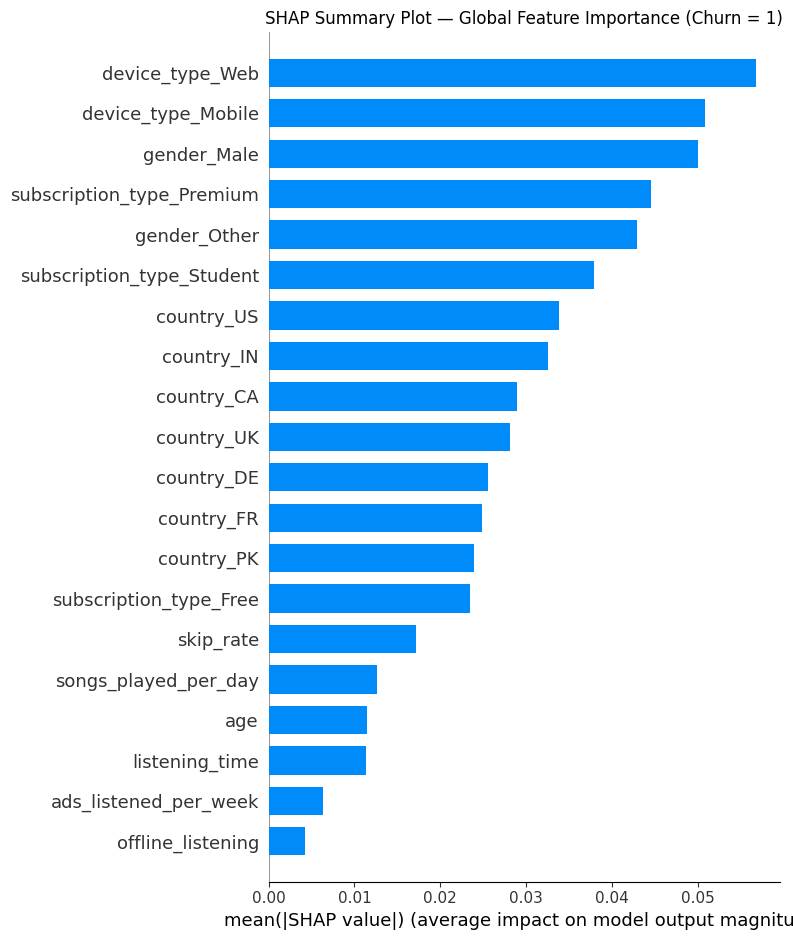

In [110]:
# --- Global Feature Importance (bar chart)
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values_class1, x_test, plot_type="bar", show=False)
plt.title("SHAP Summary Plot — Global Feature Importance (Churn = 1)")
plt.tight_layout()
plt.show()

The SHAP glbal importances ranking highlights that **user profile and platform related features** dominate in churn prediction. Meanwhile, behavioral metrics like skip rate and listening time offer supportive, but not primary.

<u><b>Detailed Feature Impact<b><u>

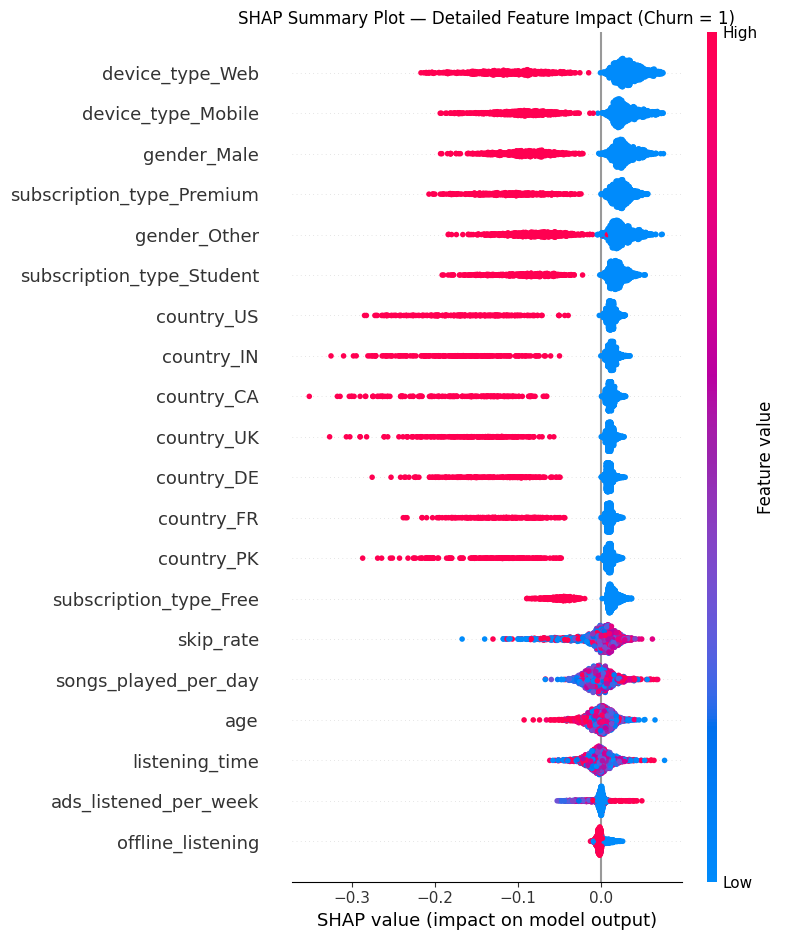

In [111]:
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values_class1, x_test, show=False)
plt.title("SHAP Summary Plot — Detailed Feature Impact (Churn = 1)")
plt.tight_layout()
plt.show()

The detailed feature impact confirms that platform usage and demographic play a primary role in increasing the probability of churn. Engagement features 

<u><b>Individual Prediction Explanation<b><u>

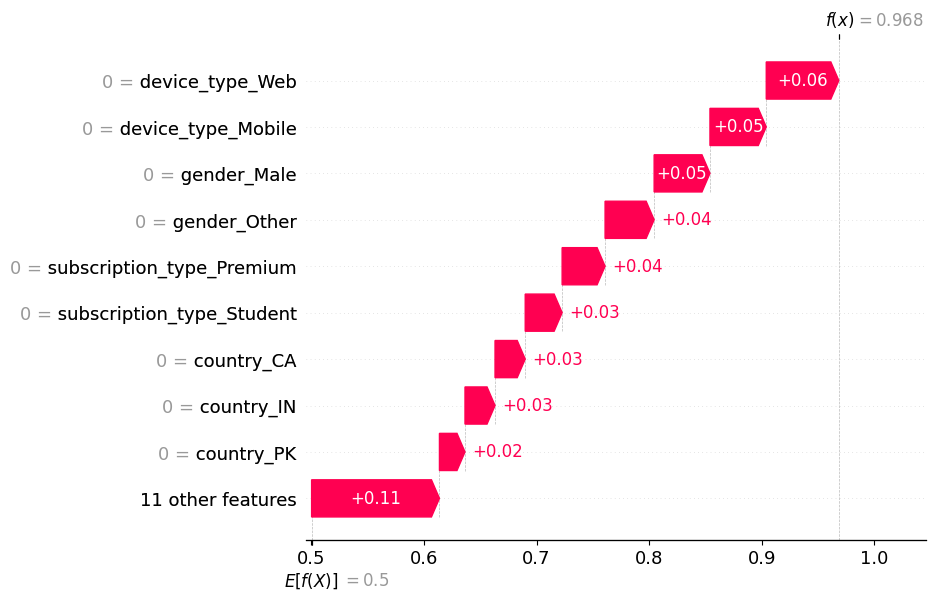

In [112]:
# Identify the index of the instance with the highest predicted churn probability
pred_probs = rf_bestmodel.predict_proba(x_test)[:,1]
highest_idx = pred_probs.argmax()
shap_val_highest = shap_values_class1[highest_idx]


# Plot waterfall for the highest predicted churn probability
shap.plots.waterfall(shap.Explanation(values=shap_val_highest,
                                      base_values=explainer.expected_value[1],
                                      data=x_test.iloc[highest_idx],
                                        feature_names=x_test.columns))

The users shows an extreamely high churn probability of 0.968. The SHAP analysis indicates that being a **free users** and users who are not from **CA,IN and PK** strongly increases churn risk. All feature contribute positively, suggesting nothing in this user's profile helps retention.

## 4.1.4 Gradient boosting

Gradient Boosting is adopted in this part to create a storng predictive model. This appraoch commbines many weak learners to from storng model that captures complex patterns in the data.

Fitting 3 folds for each of 36 candidates, totalling 108 fits
GradientBoostingClassifier completed. Table saved as 'GradientBoostingClassifier_result_table' and model as 'gradi_best_model'


Best Parameters from Grid Search: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'random_state': 42}

Baseline Model Feature Importances:



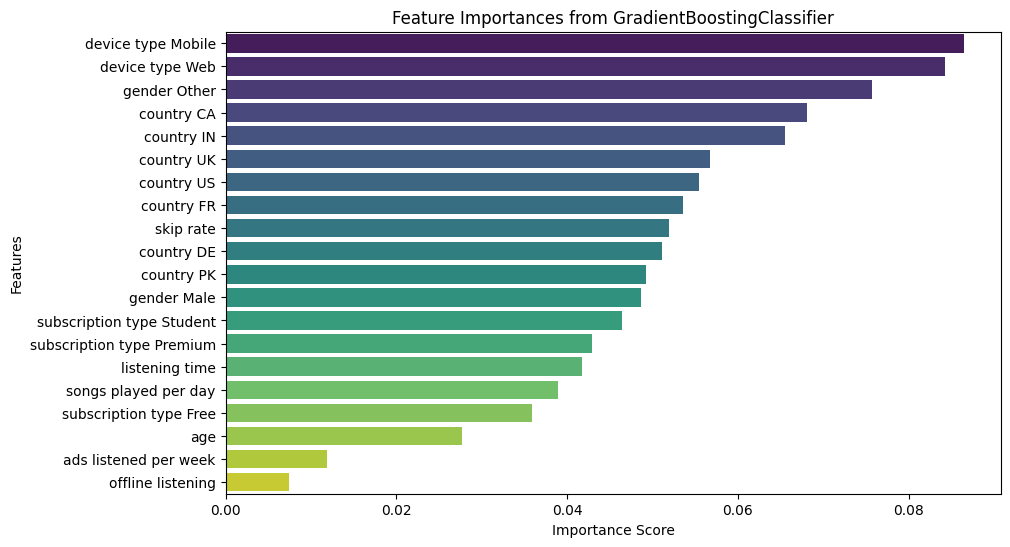


Grid Search Best Model Feature Importances:



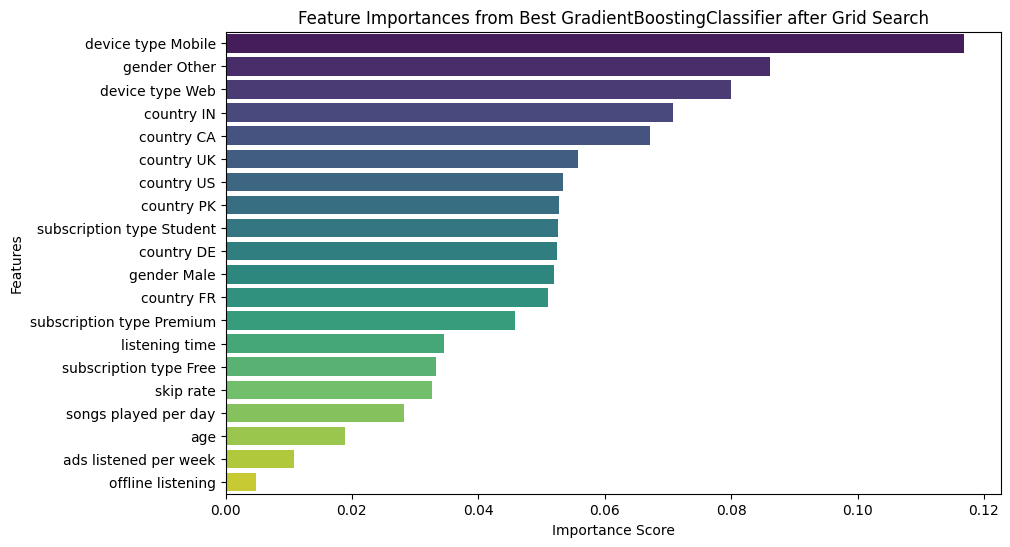


 Gradient Boosting Classifier Results:
                                                    Accuracy  Precision  \
Model                                                                     
GradientBoostingClassifier                          0.654375   0.249180   
GradientBoostingClassifier (Adjusted Threshold ...  0.342500   0.243307   
GradientBoostingClassifier GridSearchCV             0.651250   0.254658   
GradientBoostingClassifier GridSearchCV (Adjust...  0.275625   0.250493   

                                                    Recall  F1 Score   ROC AUC  
Model                                                                           
GradientBoostingClassifier                          0.1900  0.215603  0.499583  
GradientBoostingClassifier (Adjusted Threshold ...  0.7725  0.370060  0.485833  
GradientBoostingClassifier GridSearchCV             0.2050  0.227147  0.502500  
GradientBoostingClassifier GridSearchCV (Adjust...  0.9525  0.396668  0.501250  


In [113]:
# Train Gradient Boosting Classifier
model = GradientBoostingClassifier(n_estimators=200,learning_rate=0.1,random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01,0.05, 0.1, 0.2],
    'max_depth': [3,4, 5],
    'random_state': [42]
}

# Evaluate Gradient Boosting Classifier
gb_table,gb_bestmodel = eval_model(model,
              x_train=x_train,
              y_train=y_train,
              x_test=x_test,
              y_test=y_test,
              param_grid=param_grid,
              prob_threshold=0.2)
print("\n Gradient Boosting Classifier Results:")
print(gb_table)

### Feature Importance Visualization - Gradient Boosting Classifier

The following plots display the **feature importance ranking** for the Gradient Boosting model.

---

### Baseline model
- The baseline model highlights `device_type_Mobile`,`device_type_web`, and `gendor_other` as top contributor to model'prediction

-  Various **country-related variables** (e.g., `country_CA`, `country_IN`, `country_UK`) also appear influential, indicating potential geographic variation in user behavior.  

- Compared to Random Forest, the Gradient Boosting model tends to **capture more subtle feature interactions**, distributing importance across a broader set of variables.

---

### Tuned model

- After tuning ,  the feature importance pattern becomes **more focused**.

- **`device_type_Mobile`** remains the most critical predictor, but **user demographic factors** like `gender_Other`, `country_IN`, and `country_CA` gain relatively higher influence.  

- Engagement metrics such as `listening_time`, `skip_rate`, and `songs_played_per_day` still contribute but with **lower relative weight**, suggesting that the tuned model places more emphasis on **user type and regional factors** than pure behavioral activity.

---



### Model Evaluation - Gradient Boosting Classifier

The summary table summarizes the Gradient Boosting model's performance uner four configurations:

**1. Baseline Model**
- **Accuracy:** 0.65
- **Precision:** 0.25  
- **Recall:** 0.19
- **F1 Score:** 0.22
- **ROC-AUC** 0.50\
The baseline **Gradient Boosting model** performs comparably to Random Forest in terms of accuracy **65%** ut yields relatively **low recall of  19%**, indicating a conservative prediction pattern.  

---

**2. Adjusted Threshold (0.2)**
- **Accuracy:** 0.35 
- **Precision:** 0.24
- **Recall:** 0.77
- **F1 Score:** 0.37
- **ROC-AUC** 0.49\
Lowering the threshold imporve recall score dramatically to **77%** whereas, the accuracy decrease to **35%** dut to the trade off.

---

**3. GridSearchCV Tuned Model**
- **Accuracy:** 0.65
- **Precision:** 0.24
- **Recall:** 0.21
- **F1 Score:** 0.23
- **ROC-AUC**  0.50
**Grid Search CV** provides a maginal improvement in precision and ROC-AUC,indicating that default hyperparameters are already close to optimal for this data set

---

**4. Tuned Model with Adjusted Threshold (0.2)**
- **Accuracy:** 0.28
- **Precision:** 0.25  
- **Recall:** 0.95  
- **F1 Score:** 0.40
- **ROC-AUC** 0.50\
After tuning **and threshold adjustment**, recall climbs even higher to 95%,showing that the model become highly sensitive to churn case.
---

### SHAP Analysis

<u><b>SHAP Additivity Verification<b><u>

In [114]:
# Initialize SHAP tree explainer for probability output
bg = x_train.sample(200, random_state=0) 
explainer_prob = shap.TreeExplainer(
    gb_bestmodel,
    data=bg,
    model_output="probability",
    feature_perturbation="interventional"
)


# calculate SHAP values for test set
print('Calculating SHAP values')
shap_vals_prob = explainer_prob.shap_values(x_test)
base_prob = float(explainer_prob.expected_value)

print(f"Shap values is computed for {shap_vals_prob.shape[0]} predictions")
print(f"Each prediction is explained by {shap_vals_prob.shape[1]} features")

print(f"Mode expected value for churn probability: {explainer_prob.expected_value:.2f}")

# Verification of additivity property for SHAP values
i = 0 
model_pred_prob = gb_bestmodel.predict_proba(x_test.iloc[[i]])[0]
shap_sum_prob = explainer_prob.expected_value + shap_vals_prob[i].sum()
print(f"Model predicted probability: {model_pred_prob[1]:.2f}")
print(f"SHAP values sum + expected value: {shap_sum_prob:.2f}")


Calculating SHAP values
Shap values is computed for 1600 predictions
Each prediction is explained by 20 features
Mode expected value for churn probability: 0.47
Model predicted probability: 0.27
SHAP values sum + expected value: 0.27


The result validates that each SHAP value meaningfully represents how its corresponding feature shifts the prediction away from the model’s average baseline.

<u><b>Global Feature Importance<b><u>

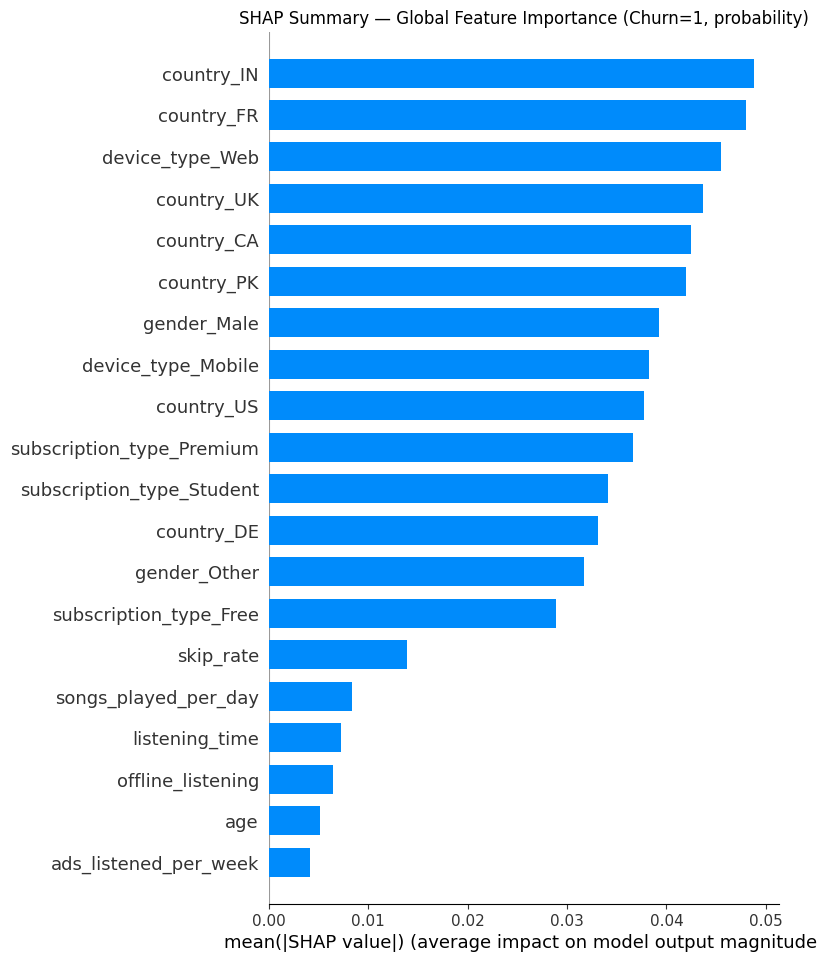

In [115]:
# plot (now units are probabilities)
shap.summary_plot(shap_vals_prob, x_test, plot_type="bar", show=False)
plt.title("SHAP Summary — Global Feature Importance (Churn=1, probability)")
plt.show()

The SHAP summary plot shows that **country** and **device type** are the most influencial factors in predicting churn, followed by **subscriptioni** type and **gender**. This indicates taht usere location aand platform choice play a significant role in chunr behaviori than listening habits or demographics.

<u><b>Detailed Feature Impact<b><u>

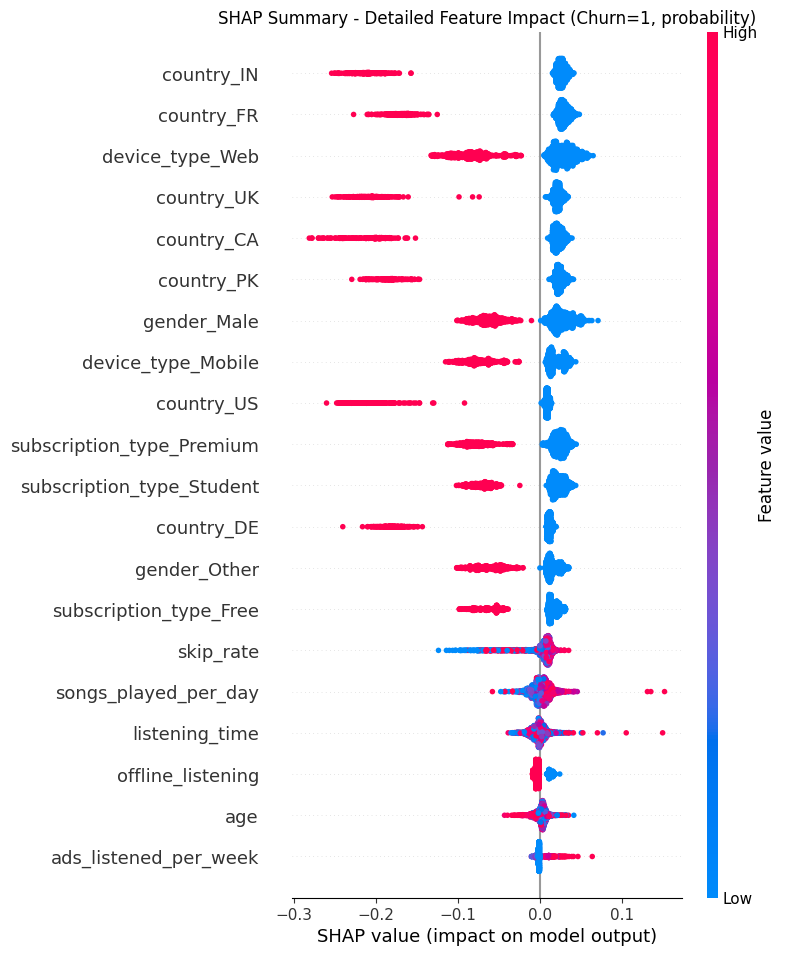

In [116]:
# plot (now units are probabilities)
shap.summary_plot(shap_vals_prob, x_test, show=False)
plt.title("SHAP Summary - Detailed Feature Impact (Churn=1, probability)")
plt.show()

The detailed plot depicts both the direction and magnitude of each feature's effect on churn. Users from India or France tend to increase churn risk, wherease those from Canada, the UK and web users reduce it. Premium and student subscription are also associated with lower churn likelihood.

<u><b>Individual Prediction Explanation<b><u>

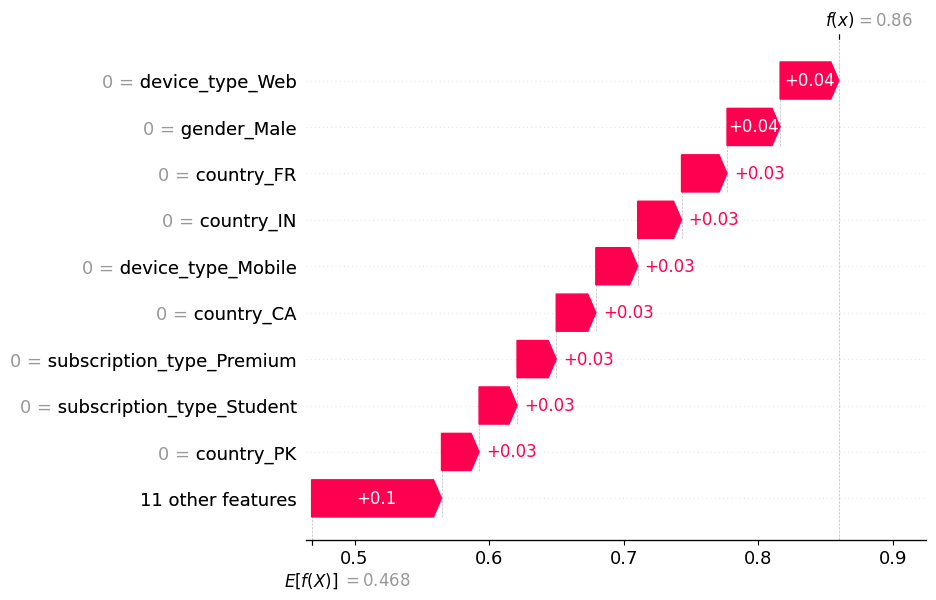

In [117]:
pred_probs = gb_bestmodel.predict_proba(x_test)[:,1]
highest_idx = pred_probs.argmax()
shap_val_highest = shap_vals_prob[highest_idx]
shap.plots.waterfall(shap.Explanation(values=shap_val_highest,
                                      base_values=base_prob,
                                      data=x_test.iloc[highest_idx],
                                      feature_names=x_test.columns))

The model predicts a high churn probability of 0.86 for this user. None of the engagement orsubscription related features show retentin strength. The user has no subscription and limted activity across devices, indicating low platform commitment. 

### 4.1.5 XG Boost

Finally, XGBoost is applied as more advanced ensemble method, with each tree correcting the errors of the previous one. This boosting approach helps the model to capture complex pattern and imporve the predictive performance

Fitting 3 folds for each of 36 candidates, totalling 108 fits
XGBClassifier completed. Table saved as 'XGBClassifier_result_table' and model as 'xgb_best_model'


Best Parameters from Grid Search: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 300, 'random_state': 42}

Baseline Model Feature Importances:



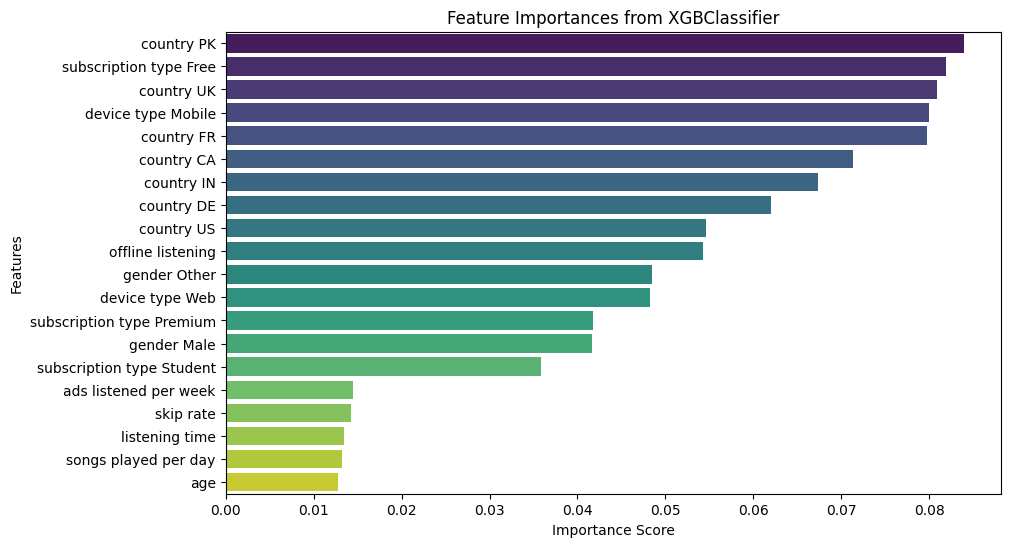


Grid Search Best Model Feature Importances:



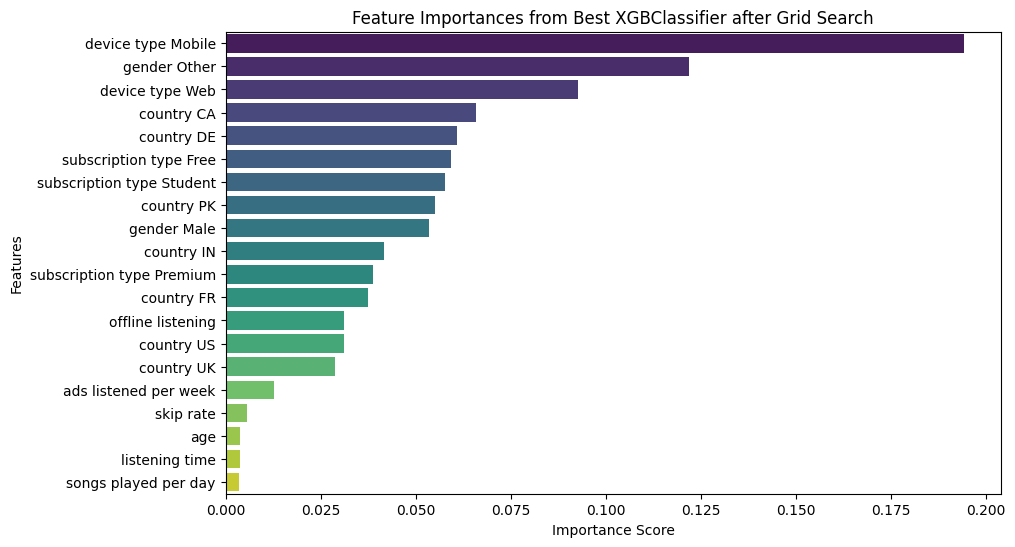


 XGBoost Classifier Results:
                                                    Accuracy  Precision  \
Model                                                                     
XGBClassifier                                       0.645000   0.240741   
XGBClassifier (Adjusted Threshold 0.2)              0.470000   0.258621   
XGBClassifier GridSearchCV                          0.654375   0.264615   
XGBClassifier GridSearchCV (Adjusted Threshold ...  0.256250   0.250631   

                                                    Recall  F1 Score   ROC AUC  
Model                                                                           
XGBClassifier                                       0.1950  0.215470  0.495000  
XGBClassifier (Adjusted Threshold 0.2)              0.6000  0.361446  0.513333  
XGBClassifier GridSearchCV                          0.2150  0.237241  0.507917  
XGBClassifier GridSearchCV (Adjusted Threshold ...  0.9925  0.400202  0.501667  


In [118]:
# Train XGBoost Classifier
xg = XGBClassifier(use_label_encoder=False,eval_metric='logloss',random_state=42)
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01,0.05, 0.1, 0.2],
    'max_depth': [3,4, 5],
    'random_state': [42]
}

# Evaluate XGBoost Classifier
xg_table,xg_bestmodel = eval_model(xg,
              x_train=x_train,
              y_train=y_train,
              x_test=x_test,
              y_test=y_test,
              param_grid=param_grid,
              prob_threshold=0.2)

print("\n XGBoost Classifier Results:")
print(xg_table)

### Feature Importance Visualization - XGBoost Classifier

The following plots display the **feature importance ranking** for the XGBoost model.

---

### Baseline model
- The baseline model highlights `country_PK`,`subscription-type_Free`, and `device_type_Mobile` as top contributor to model'prediction.

- Sevaral country varaible also rank highly,meaning that regional differences in churn behavior.

- Engagement features shos lower realtive importance.

---

### Tuned model

- After tuning , the feature importance pattern becomes **more concentrated**, with `device_type_Mobile`  emerging as the strongest predictor.

- **`gendor_Other` and `device_type_Web` ** gain higher influence, while country and subscription features remain moderately important.  

- This model shifts focus from broad regional factors to device usage and demographic differences.

---

### Model Evaluation - XGBoost Classifier

The summary table summarizes the Gradient Boosting model's performance uner four configurations:

**1. Baseline Model**
- **Accuracy:** 0.65
- **Precision:** 0.24 
- **Recall:** 0.20
- **F1 Score:** 0.22
- **ROC-AUC** 0.50\
The baseline **XGBoost model** achieves an accuracy of **65%**,similar to Gradient Boosting, but with **moderate precision of 24%** and  **low recall of  20%**, indicating that model correctly identifies only a small portion of churned users.  

---

**2. Adjusted Threshold (0.2)**
- **Accuracy:** 0.47
- **Precision:** 0.6
- **Recall:** 0.60
- **F1 Score:** 0.36
- **ROC-AUC** 0.51\
Reducing the threshold imporve recall score dramatically to **50%**. This sho a strong ability to capture churners at the cost of lower accuracy. 

---

**3. GridSearchCV Tuned Model**
- **Accuracy:** 0.65
- **Precision:** 0.26
- **Recall:** 0.22
- **F1 Score:** 0.24
- **ROC-AUC**  0.51\
After hyperparameter tunning, XGBoost yields a **slight imporvement in precision and ROC-AUC**. Thus, the default may close to optiaml for this dataset.
---

**4. Tuned Model with Adjusted Threshold (0.2)**
- **Accuracy:** 0.26
- **Precision:** 0.25  
- **Recall:** 0.99  
- **F1 Score:** 0.40
- **ROC-AUC** 0.50\
Combining **tunning** and **lower threshold** produces an extreamely high recall of 99%, suggesting that the model nearly capture all churn case. However, this come with a cost of dramatic drop in accuracy.
---

### SHAP Analysis

<u><b>SHAP Additivity Verification<b><u>

In [119]:
# Initialize SHAP tree explainer for probability output
bg = x_train.sample(200, random_state=0) 
explainer_prob = shap.TreeExplainer(
    xg_bestmodel,
    data=bg,
    model_output="probability",
    feature_perturbation="interventional"
)


# calculate SHAP values for test set
print('Calculating SHAP values')
shap_vals_prob = explainer_prob.shap_values(x_test)
base_prob = float(explainer_prob.expected_value)

print(f"Shap values is computed for {shap_vals_prob.shape[0]} predictions")
print(f"Each prediction is explained by {shap_vals_prob.shape[1]} features")

print(f"Mode expected value for churn probability: {explainer_prob.expected_value:.2f}")

# Verification of additivity property for SHAP values
i = 0 
model_pred_prob = xg_bestmodel.predict_proba(x_test.iloc[[i]])[0]
shap_sum_prob = explainer_prob.expected_value + shap_vals_prob[i].sum()
print(f"Model predicted probability: {model_pred_prob[1]:.2f}")
print(f"SHAP values sum + expected value: {shap_sum_prob:.2f}")


Calculating SHAP values
Shap values is computed for 1600 predictions
Each prediction is explained by 20 features
Mode expected value for churn probability: 0.48
Model predicted probability: 0.31
SHAP values sum + expected value: 0.31


The SHAP verification confirms the additivity property. This enusres that SHAP correctly decomposes the prediction into interpretable featue effects.

<u><b>Global Feature Importance<b><u>

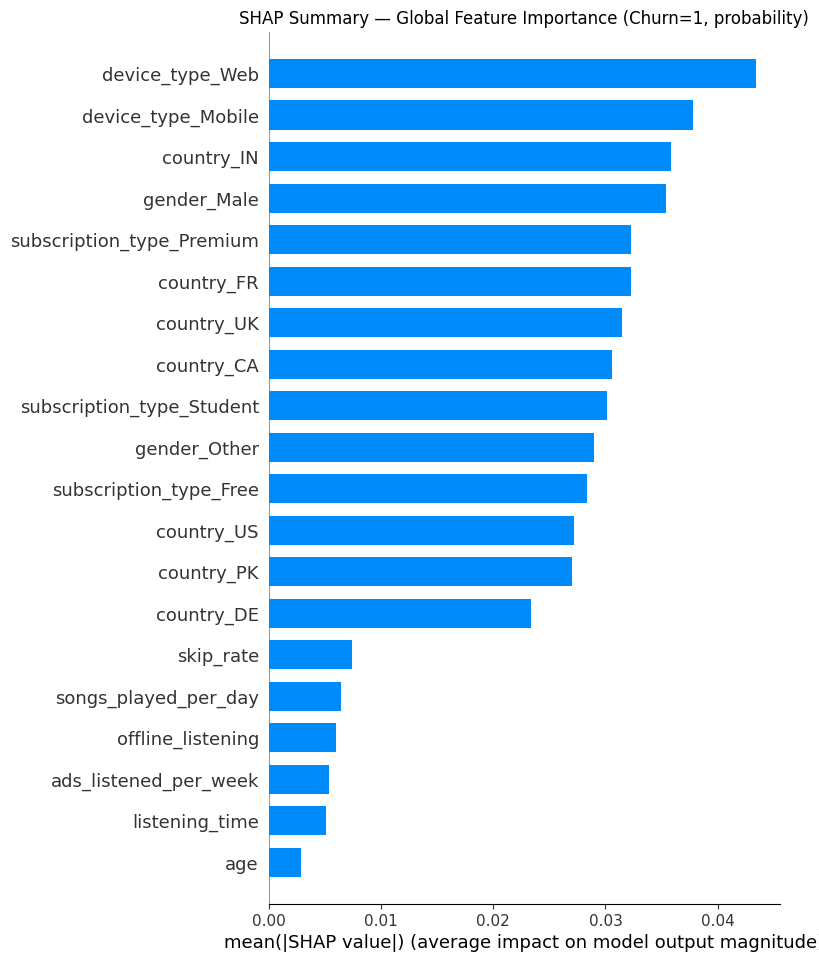

In [120]:
shap.summary_plot(shap_vals_prob, x_test, plot_type="bar", show=False)
plt.title("SHAP Summary — Global Feature Importance (Churn=1, probability)")
plt.show()

The SHAP summary plot depicts that **device related features** have the strongest overall influence on churn predictions. This indicates that user behavior differs significantly across platforms, **Country** and **subscription type** also play important roles. The model places greater emphaisis on **user type** and **platform characteristic** than engagement activity.

<u><b>Detailed Feature Impact<b><u>

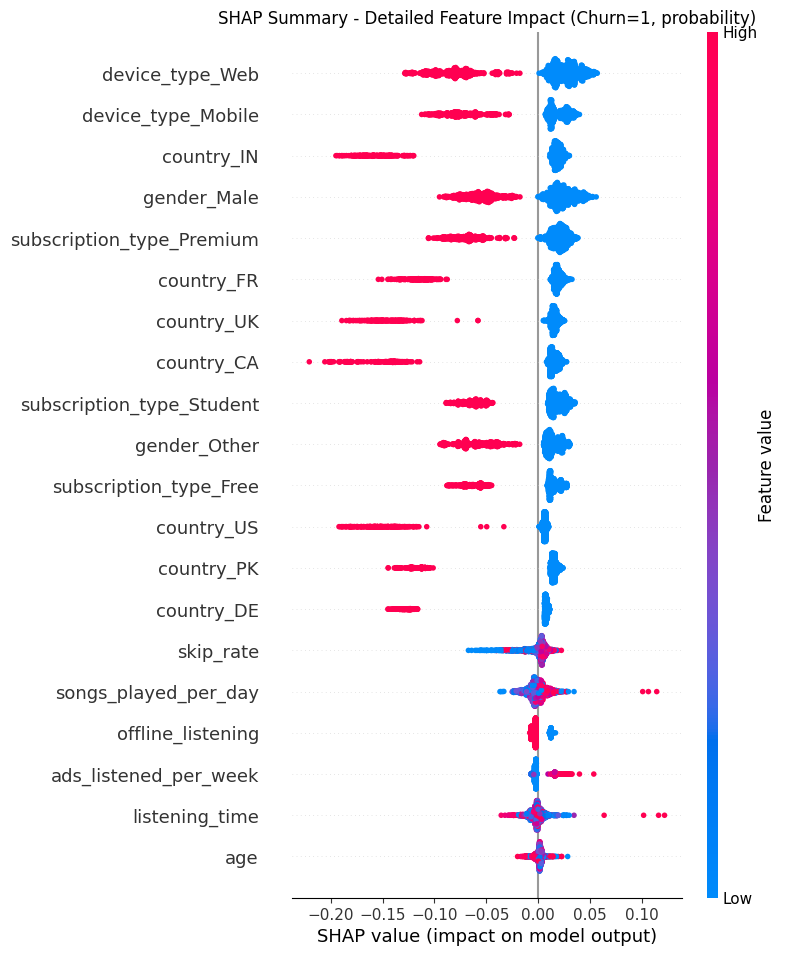

In [121]:
# plot (now units are probabilities)
shap.summary_plot(shap_vals_prob, x_test, show=False)
plt.title("SHAP Summary - Detailed Feature Impact (Churn=1, probability)")
plt.show()

This SHAP detailed plot shows that **web devices** tend to have higher churn probabilities, while thoe on mobile associated with lower churn. Both country and subscription variables also contribute into churn likelihood. Behavioral variables show relatively minor influence on the churn prediction.

<u><b>Individual Prediction Explanation<b><u>

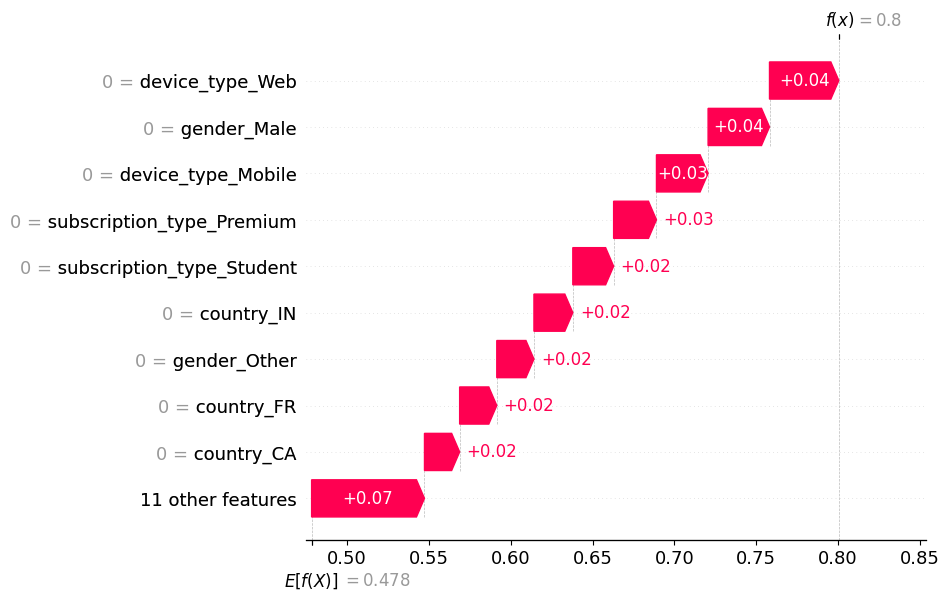

In [122]:
pred_probs = gb_bestmodel.predict_proba(x_test)[:,1]
highest_idx = pred_probs.argmax()
shap_val_highest = shap_vals_prob[highest_idx]
shap.plots.waterfall(shap.Explanation(values=shap_val_highest,
                                      base_values=base_prob,
                                      data=x_test.iloc[highest_idx],
                                      feature_names=x_test.columns))

The SHAP waterfall plot shows a prediction of churn probability of 0.80. This is significant higher above the baseline. All features have positive shap value, meaning each factor increases a likelihood of churn for this user. The most influence contributors include device type varaiables, gendor and subscription types. Geographic attributes also slightly raise churn probability.

## 5.Model Comparision

In [123]:
# Combine all model result tables
all_models = pd.concat([logit_table,dt_table,rf_table,gb_table,xg_table],axis=0)

<u><b>5.1 Base Model Comparision<b><u>

In [124]:
# filter only base model results
base_models = all_models[
    ~all_models.index.str.contains('Adjusted|GridSearch', case=False)
]
base_models = base_models.reset_index().rename(columns={'index':'Model'})
base_models.sort_values(by='Recall',ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,DecisionTreeClassifier,0.631250,0.228571,0.2000,0.213333,0.487500
0,LogisticRegression,0.652500,0.251592,0.1975,0.221289,0.500833
4,XGBClassifier,0.645000,0.240741,0.1950,0.215470,0.495000
3,GradientBoostingClassifier,0.654375,0.249180,0.1900,0.215603,0.499583
2,RandomForestClassifier,0.695000,0.298165,0.1625,0.210356,0.517500


The comparision of base model shows that `Decision tree` has the highest recall of 0.2, compared to other model. It slightly outperforming `Logistic Regression`, `Gradient Boosting`, and `XGBoost`, which yield similar recall level. This indicates that all models struggle to correctly identify churn cases.

<u><b>5.2 Baseline with Adjusted Threshold (0.2) Comparision<b><u>

In [125]:
# filter only adjusted threshold model results
base_adj_models = all_models[
    all_models.index.str.contains('Adjusted', case=False) &
    ~all_models.index.str.contains('GridSearch', case=False)
]
base_adj_models = base_adj_models.reset_index().rename(columns={'index':'Model'})
base_adj_models.sort_values(by='Recall',ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,DecisionTreeClassifier (Adjusted Threshold 0.2),0.270625,0.249510,0.9550,0.395650,0.498750
2,RandomForestClassifier (Adjusted Threshold 0.2),0.350000,0.259398,0.8625,0.398844,0.520833
3,GradientBoostingClassifier (Adjusted Threshold...,0.342500,0.243307,0.7725,0.370060,0.485833
0,LogisticRegression (Adjusted Threshold 0.2),0.354375,0.244964,0.7600,0.370506,0.489583
4,XGBClassifier (Adjusted Threshold 0.2),0.470000,0.258621,0.6000,0.361446,0.513333


After lowering the threshold to 0.2, all model show a significant increase in recall score, confirming that this adjustment ensures to detect mor churn cases. `Decision Tree` has the highest recall of **0.96**, forllowed by `Random Forest`**(0.86)** and `Gradient Booosting`**(0.77)**.

While accuracy drop to **27-47%**, this trade-off is expected when optimizing for recall.

<u><b>5.3 Grid Search Model<b><u>

In [126]:
# filter only grid search model results
grid_models = all_models[
    all_models.index.str.contains('GridSearch', case=False) &
    ~all_models.index.str.contains('Adjusted', case=False)
]
grid_models = grid_models.reset_index().rename(columns={'index':'Model'})
grid_models.sort_values(by='Recall',ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,DecisionTreeClassifier GridSearchCV,0.602500,0.223005,0.2375,0.230024,0.480833
4,XGBClassifier GridSearchCV,0.654375,0.264615,0.2150,0.237241,0.507917
3,GradientBoostingClassifier GridSearchCV,0.651250,0.254658,0.2050,0.227147,0.502500
0,LogisticRegression GridSearchCV,0.665625,0.250923,0.1700,0.202683,0.500417
2,RandomForestClassifier GridSearchCV,0.683125,0.272340,0.1600,0.201575,0.508750


All model show only slight performance improvements compared the base model. `Decision Tree` achieves the highest recall(0.24), slightly outperforming `XGBoost`(0.22) and `Gradient Boosting`(0.21).

Overall, the tunning imporves precision and stability but does no dramatically increase recall.

<u><b>5.4 Grid Search Model (adjusted threshold 0.2)<b><u>

In [127]:
# filter only grid search adjusted threshold model results
grid_adj_models = all_models[
    all_models.index.str.contains('GridSearch', case=False) &
    all_models.index.str.contains('Adjusted', case=False)
]
grid_adj_models = grid_adj_models.reset_index().rename(columns={'index':'Model'})
grid_adj_models.sort_values(by='Recall',ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
4,XGBClassifier GridSearchCV (Adjusted Threshold...,0.256250,0.250631,0.9925,0.400202,0.501667
3,GradientBoostingClassifier GridSearchCV (Adjus...,0.275625,0.250493,0.9525,0.396668,0.501250
2,RandomForestClassifier GridSearchCV (Adjusted ...,0.311250,0.251768,0.8900,0.392503,0.504167
1,DecisionTreeClassifier GridSearchCV (Adjusted ...,0.358125,0.251781,0.7950,0.382441,0.503750
0,LogisticRegression GridSearchCV (Adjusted Thre...,0.360625,0.244463,0.7450,0.368128,0.488750


After combining hyperparameter tuning with a lower decision threshold (0.2), all models show a substantial improvement in recall, confirming higher sensitivity to churn cases.

The `XGBoost` achieves the highest recall (0.99), followed closely by `Gradient Boosting` (0.95) and `Random Forest` (0.89), all with recall above 0.75.

However, this improvement comes with a significant drop in accuracy, reflecting the trade-off between identifying more churners and increasing false positives.

## 6. Overall Model Summary

In [128]:
# all models summary
all_models.sort_values(by='Recall',ascending=False)

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
XGBClassifier GridSearchCV (Adjusted Threshold 0.2),0.256250,0.250631,0.9925,0.400202,0.501667
DecisionTreeClassifier (Adjusted Threshold 0.2),0.270625,0.249510,0.9550,0.395650,0.498750
GradientBoostingClassifier GridSearchCV (Adjusted Threshold 0.2),0.275625,0.250493,0.9525,0.396668,0.501250
RandomForestClassifier GridSearchCV (Adjusted Threshold 0.2),0.311250,0.251768,0.8900,0.392503,0.504167
RandomForestClassifier (Adjusted Threshold 0.2),0.350000,0.259398,0.8625,0.398844,0.520833
DecisionTreeClassifier GridSearchCV (Adjusted Threshold 0.2),0.358125,0.251781,0.7950,0.382441,0.503750
GradientBoostingClassifier (Adjusted Threshold 0.2),0.342500,0.243307,0.7725,0.370060,0.485833
LogisticRegression (Adjusted Threshold 0.2),0.354375,0.244964,0.7600,0.370506,0.489583
LogisticRegression GridSearchCV (Adjusted Threshold 0.2),0.360625,0.244463,0.7450,0.368128,0.488750


When comparing all models, the result shows that threshold adjustment hast the most significant impact on improving recall.

The `XGBoost` (GridSearchCV + Adjusted Threshold 0.2) has the highest recall of 0.99, followed by `Decision Tree`(0.95) and `Gradient Boosting` (0.95) configurations. These confirm that tuned and threshold adjustment for ensemble method are the most effective for identifying churn.

However, these improvements come with a major drop in accuracy (around 0.25–0.36), indicating an expected trade-off where the models capture nearly all churners but produce more false positives.

# 7. Conclusion

In churn prediction, recall is the key priority, as identifying potential churners is more valuable than avoiding false positives.

Therefore, the tuned and threshold-adjusted XGBoost model is the most suitable approach, offering the strongest ability to detect churners while maintaining stable model behavior.

Although it sacrifices accuracy, this trade-off aligns with business objectives,enabling proactive customer-retention strategies and minimizing potential revenue loss.